In [57]:
install_packages <- function() {
  install.packages('rsample')
  install.packages('randomForest')
  install.packages('car')
  install.packages('MASS')
  install.packages('pROC')
  install.packages('caret')
  install.packages("naniar")
}

In [58]:
# install_packages()

In [59]:
df <- read.csv('/content/Appendicitis.csv')[-(59:69)]
str(df)

'data.frame':	781 obs. of  58 variables:
 $ Age                             : num  12.7 14.1 14.1 16.4 11.1 ...
 $ BMI                             : num  16.9 31.9 23.3 20.6 16.9 30.7 19.4 NA 15.7 14.9 ...
 $ Sex                             : chr  "female" "male" "female" "female" ...
 $ Height                          : num  148 147 163 165 163 121 140 NA 131 174 ...
 $ Weight                          : num  37 69.5 62 56 45 45 38.5 21.5 26.7 45.5 ...
 $ Length_of_Stay                  : int  3 2 4 3 3 3 3 2 3 3 ...
 $ Management                      : chr  "conservative" "conservative" "conservative" "conservative" ...
 $ Severity                        : chr  "uncomplicated" "uncomplicated" "uncomplicated" "uncomplicated" ...
 $ Diagnosis_Presumptive           : chr  "appendicitis" "appendicitis" "appendicitis" "appendicitis" ...
 $ Diagnosis                       : chr  "appendicitis" "no appendicitis" "no appendicitis" "no appendicitis" ...
 $ Alvarado_Score                  : int

In [60]:
#Deal with missing value
char_cols <- sapply(df, is.character)
char_cols_names <- names(df)[char_cols]
df[, char_cols_names] <- lapply(df[, char_cols_names], function(x) {
     x[x == ""] <- NA
     x
   })
df[, char_cols_names] <- lapply(df[, char_cols_names], factor)
str(df)

'data.frame':	781 obs. of  58 variables:
 $ Age                             : num  12.7 14.1 14.1 16.4 11.1 ...
 $ BMI                             : num  16.9 31.9 23.3 20.6 16.9 30.7 19.4 NA 15.7 14.9 ...
 $ Sex                             : Factor w/ 2 levels "female","male": 1 2 1 1 1 2 1 1 2 2 ...
 $ Height                          : num  148 147 163 165 163 121 140 NA 131 174 ...
 $ Weight                          : num  37 69.5 62 56 45 45 38.5 21.5 26.7 45.5 ...
 $ Length_of_Stay                  : int  3 2 4 3 3 3 3 2 3 3 ...
 $ Management                      : Factor w/ 4 levels "conservative",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Severity                        : Factor w/ 2 levels "complicated",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ Diagnosis_Presumptive           : Factor w/ 16 levels "abdominelle Adh?sionen, chron. Unterbauchbeschwerden mit Subileussymptomatik",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ Diagnosis                       : Factor w/ 2 levels "appendicitis",..: 1 2 2 2 1 2 2 2 2 1 ...


In [61]:
sum(is.na(df))
#Lots of missing value

[1] 13950

In [62]:
missing_counts <- colSums(is.na(df))
missing_table <- as.data.frame(t(missing_counts))
print(missing_table)
#Some columns are mostly NA

  Age BMI Sex Height Weight Length_of_Stay Management Severity
1   0  26   1     25      2              3          0        0
  Diagnosis_Presumptive Diagnosis Alvarado_Score Paedriatic_Appendicitis_Score
1                     1         1             51                            51
  Appendix_on_US Appendix_Diameter Migratory_Pain Lower_Right_Abd_Pain
1              4               283              8                    7
  Contralateral_Rebound_Tenderness Coughing_Pain Nausea Loss_of_Appetite
1                               14            15      7                9
  Body_Temperature WBC_Count Neutrophil_Percentage Segmented_Neutrophils
1                6         5                   102                   727
  Neutrophilia RBC_Count Hemoglobin RDW Thrombocyte_Count Ketones_in_Urine
1           49        17         17  25                17              199
  RBC_in_Urine WBC_in_Urine CRP Dysuria Stool Peritonitis Psoas_Sign
1          205          198  10      28    16           8      

In [63]:
#Remove columns with missing value > 100
#And remove row with missing value altogether
#Except for Appendix_Diameter which is one of the best indicator of appendicitis
to_remove <- names(missing_counts[missing_counts>100])
to_remove <- to_remove[! to_remove %in% 'Appendix_Diameter']
df <- df[, !(names(df) %in% to_remove)]

In [64]:
appendix_diameter_col <- df[, c("Appendix_Diameter")]
names(appendix_diameter_col) <- rownames(df)
cols_to_check <- names(df)[!names(df) %in% 'Appendix_Diameter']
df <- na.omit(df[, cols_to_check])
df <- merge(df, data.frame(Appendix_Diameter = appendix_diameter_col), by = "row.names", all.x = TRUE)
# df <- df[,!(names(df) %in% 'Row.names')]
str(df)

'data.frame':	589 obs. of  36 variables:
 $ Row.names                       : chr  "1" "10" "100" "101" ...
 $ Age                             : num  12.7 14.3 11.2 12 11.9 ...
 $ BMI                             : num  16.9 14.9 14.9 15.9 18.7 20.2 18.5 23.5 15.9 19.5 ...
 $ Sex                             : Factor w/ 2 levels "female","male": 1 2 2 1 2 1 1 2 1 1 ...
 $ Height                          : num  148 174 142 144 162 159 174 146 123 152 ...
 $ Weight                          : num  37 45.5 30 33 49 51 56 49.5 23.5 44.8 ...
 $ Length_of_Stay                  : int  3 3 3 2 3 4 2 3 3 3 ...
 $ Management                      : Factor w/ 4 levels "conservative",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Severity                        : Factor w/ 2 levels "complicated",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ Diagnosis_Presumptive           : Factor w/ 16 levels "abdominelle Adh?sionen, chron. Unterbauchbeschwerden mit Subileussymptomatik",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ Diagnosis                     

In [65]:
table(is.na(df$Appendix_Diameter), df$Appendix_on_US)

#Remove data point that doesn't make sense
df <- df[!(!is.na(df$Appendix_Diameter) & df$Appendix_on_US == 'no'),]
df <- df[!(is.na(df$Appendix_Diameter) & df$Appendix_on_US == 'yes'),]
table(is.na(df$Appendix_Diameter), df$Appendix_on_US)

       
         no yes
  FALSE   4 392
  TRUE  188   5

       
         no yes
  FALSE   0 392
  TRUE  188   0

In [66]:
missing_counts <- colSums(is.na(df))
missing_table <- as.data.frame(t(missing_counts))
print(missing_table)

  Row.names Age BMI Sex Height Weight Length_of_Stay Management Severity
1         0   0   0   0      0      0              0          0        0
  Diagnosis_Presumptive Diagnosis Alvarado_Score Paedriatic_Appendicitis_Score
1                     0         0              0                             0
  Appendix_on_US Migratory_Pain Lower_Right_Abd_Pain
1              0              0                    0
  Contralateral_Rebound_Tenderness Coughing_Pain Nausea Loss_of_Appetite
1                                0             0      0                0
  Body_Temperature WBC_Count Neutrophilia RBC_Count Hemoglobin RDW
1                0         0            0         0          0   0
  Thrombocyte_Count CRP Dysuria Stool Peritonitis Psoas_Sign US_Performed
1                 0   0       0     0           0          0            0
  US_Number Free_Fluids Appendix_Diameter
1         0           0               188


In [67]:
#Remove NA and replace with 0 (missing indicator)
df$Appendix_Diameter[is.na(df$Appendix_Diameter)] <- 0

In [68]:
#Inspecting factor with more than 2 levels
factor_cols <- names(df)[sapply(df, is.factor)]
for (col in factor_cols) {
  num_levels <- nlevels(df[[col]])
  if (num_levels > 2) {
    cat("Factor:", col, "\n")
    cat("Levels:", levels(df[[col]]), "\n\n")
  }
}
#Diagnosis_Presumptive among others should probably be removed

Factor: Management 
Levels: conservative primary surgical secondary surgical simultaneous appendectomy 

Factor: Diagnosis_Presumptive 
Levels: abdominelle Adh?sionen, chron. Unterbauchbeschwerden mit Subileussymptomatik Adh?sionen des Colon ascendens appendicitis Appendizitis, Lymphadenitis mesenterialis Appendizitis/ Lymphadenitis mesenterialis Bridenileus chronische Appendizitis chronische Bauchschmerzen diabetische Ketoazidose, Myokarditis Gastroenteritis gedeckt perforierte Appendizitis no appendicitis Ovarialtorsion prolongierte Gastroenteritis Sepsis mit Begleitappendizitis Torsion der Adnexe 

Factor: Stool 
Levels: constipation constipation, diarrhea diarrhea normal 

Factor: Peritonitis 
Levels: generalized local no 



In [69]:
#Remove irrelevant variables
df <- df[,!names(df) %in% c('Length_of_Stay', 'Diagnosis_Presumptive', 'US_Number', 'US_Performed', 'Row.names')]
str(df)
#Diagnosis, Management and Severity are potential response for prediction

'data.frame':	580 obs. of  31 variables:
 $ Age                             : num  12.7 14.3 11.2 12 11.9 ...
 $ BMI                             : num  16.9 14.9 14.9 15.9 18.7 20.2 18.5 23.5 15.9 19.5 ...
 $ Sex                             : Factor w/ 2 levels "female","male": 1 2 2 1 2 1 1 2 1 1 ...
 $ Height                          : num  148 174 142 144 162 159 174 146 123 152 ...
 $ Weight                          : num  37 45.5 30 33 49 51 56 49.5 23.5 44.8 ...
 $ Management                      : Factor w/ 4 levels "conservative",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Severity                        : Factor w/ 2 levels "complicated",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ Diagnosis                       : Factor w/ 2 levels "appendicitis",..: 1 1 1 2 2 1 1 1 1 2 ...
 $ Alvarado_Score                  : int  4 4 6 3 7 7 8 4 9 2 ...
 $ Paedriatic_Appendicitis_Score   : int  3 4 6 5 6 5 7 3 7 2 ...
 $ Appendix_on_US                  : Factor w/ 2 levels "no","yes": 2 2 2 1 1 2 2 2 2 1 ...
 $ Migr

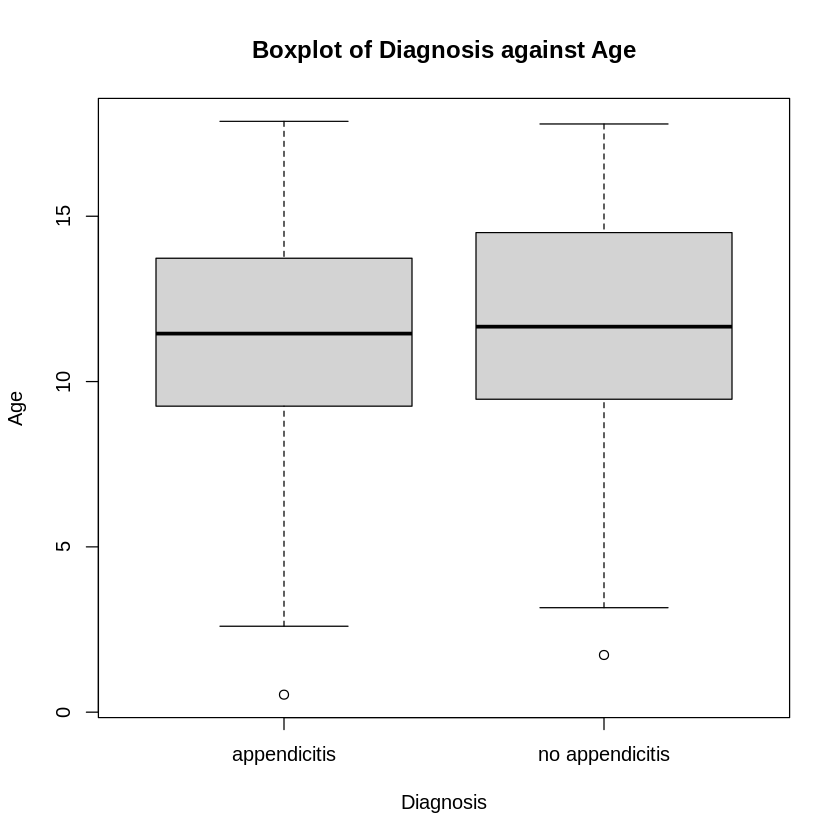

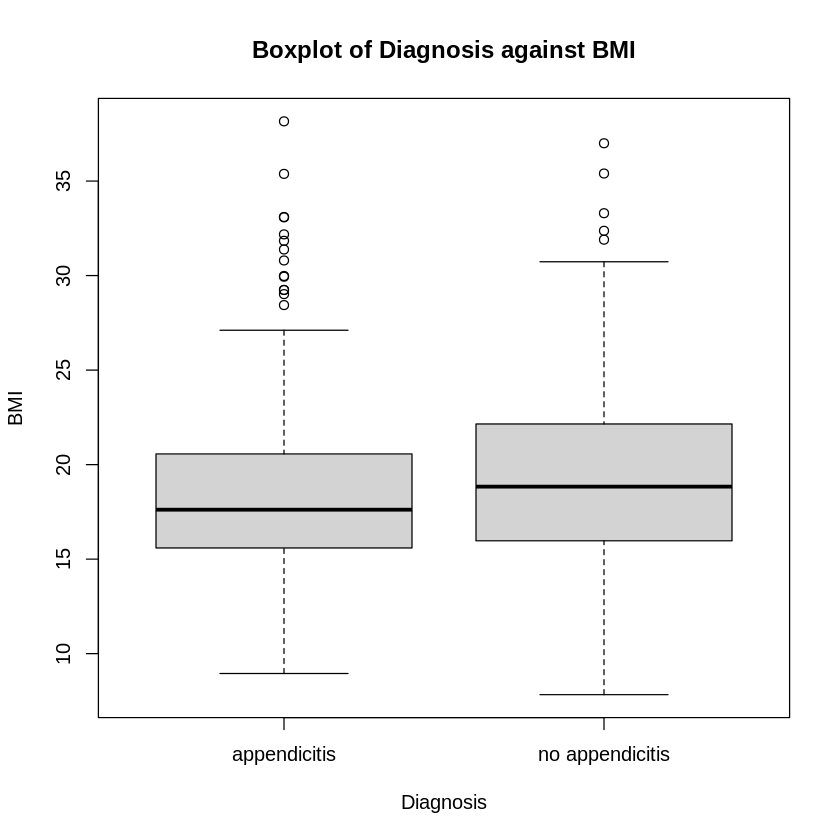

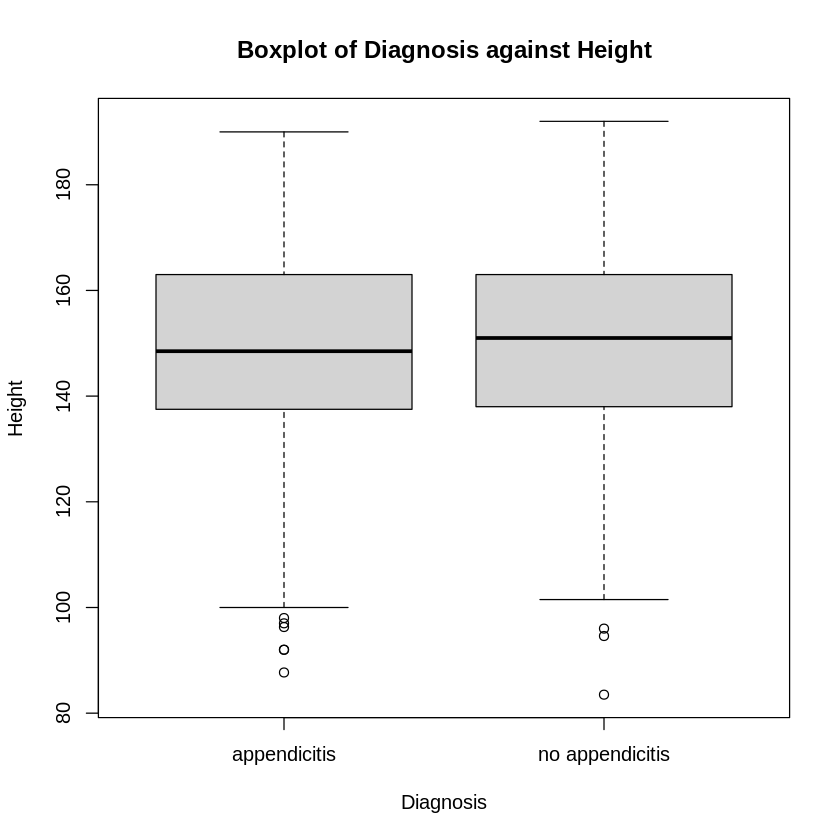

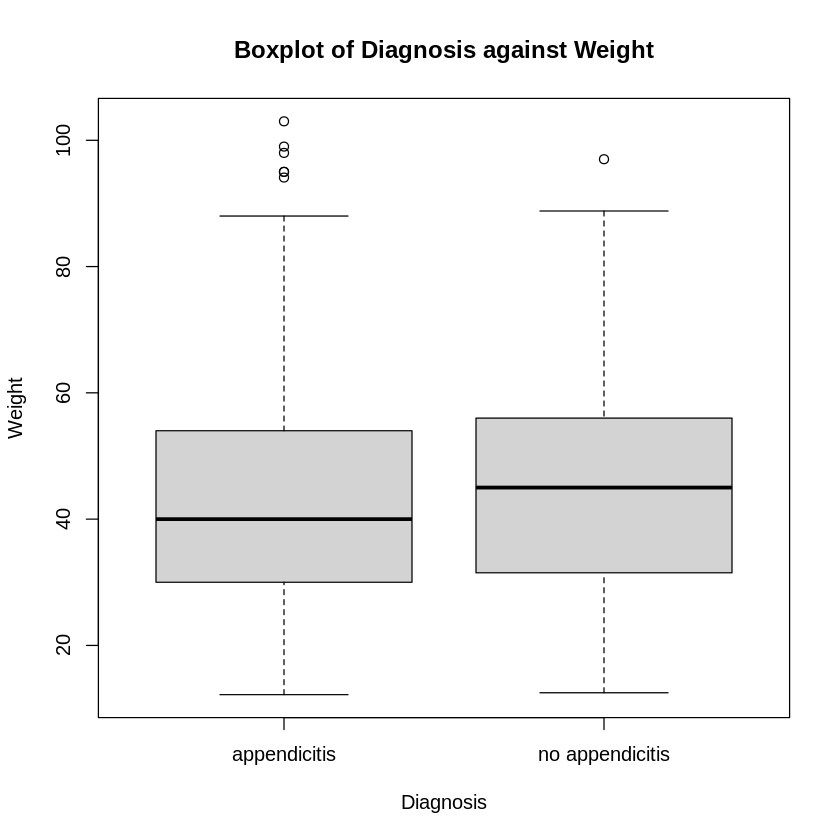

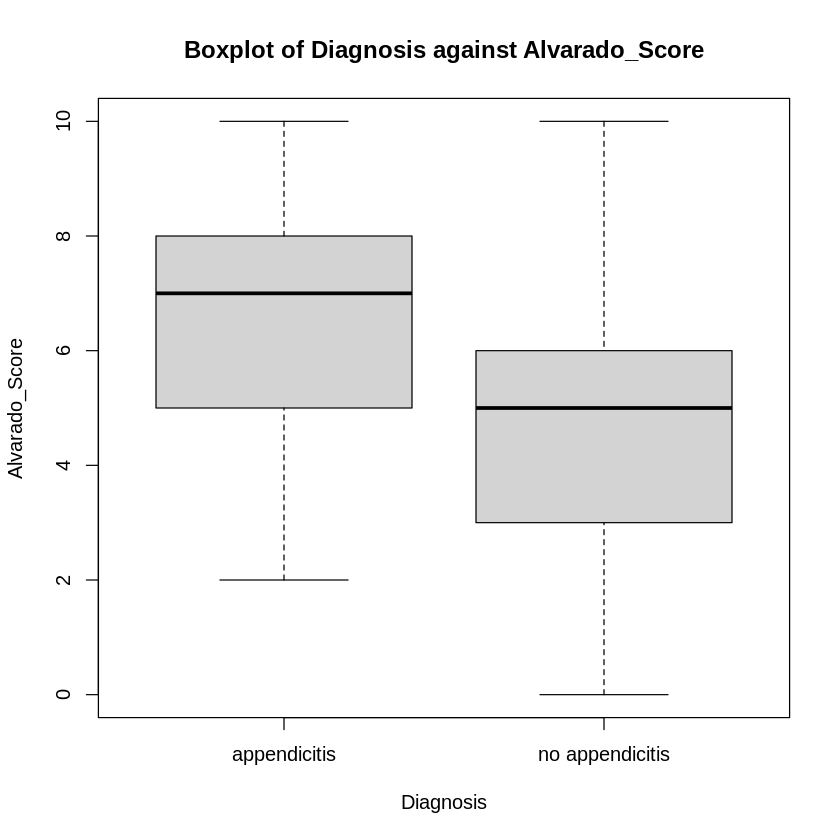

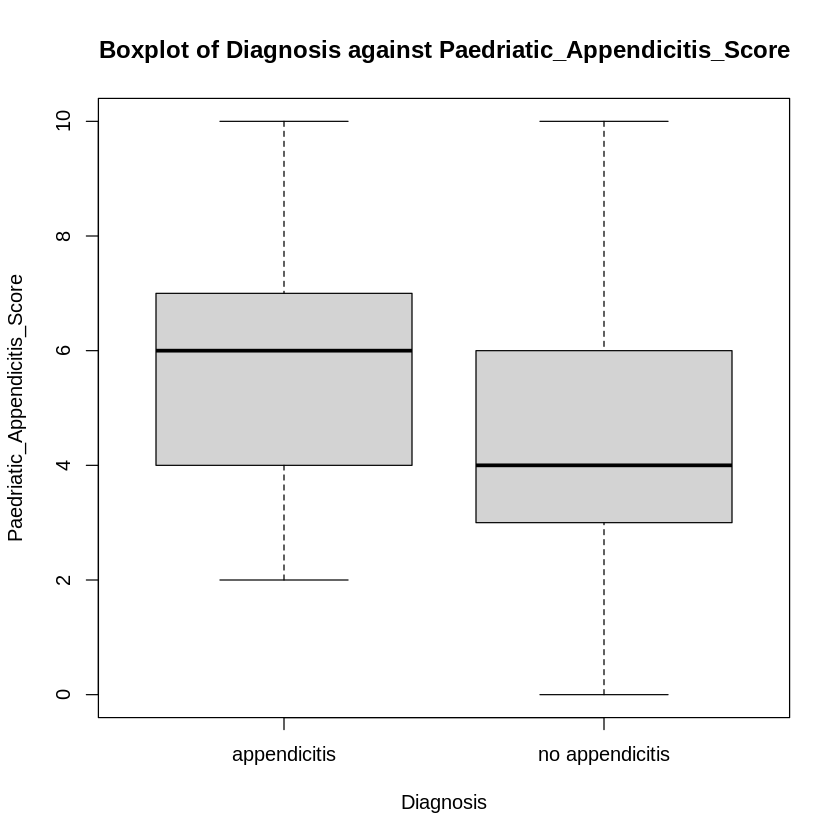

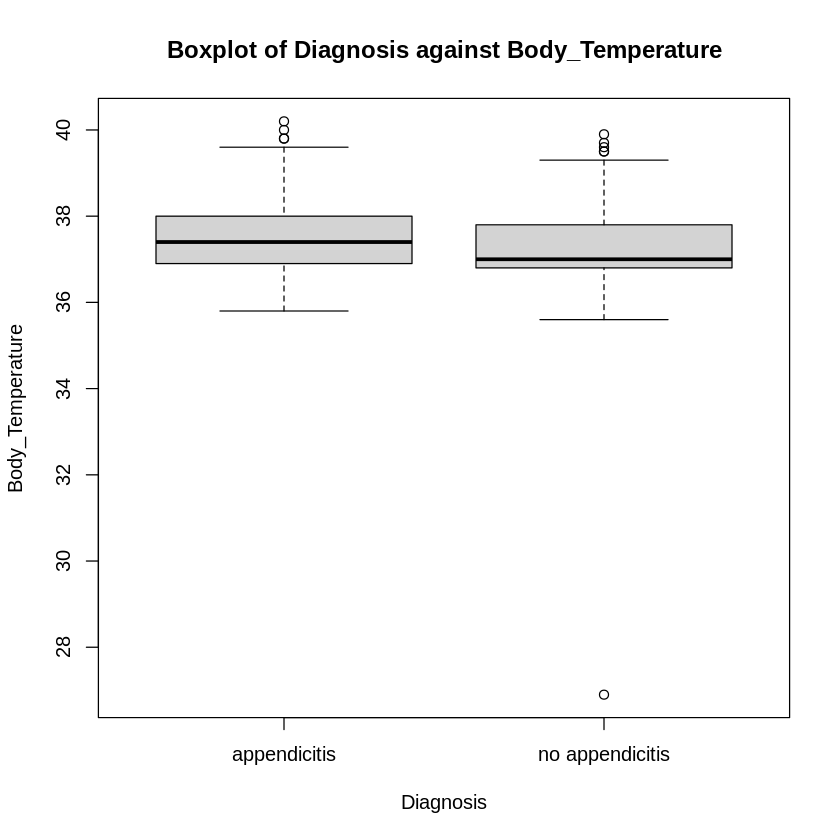

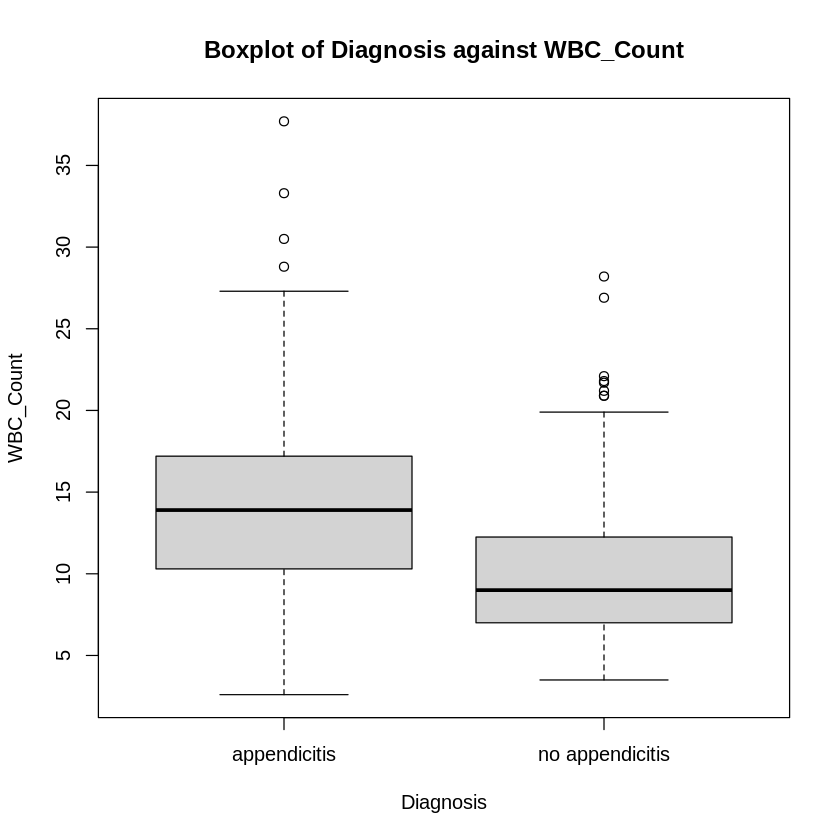

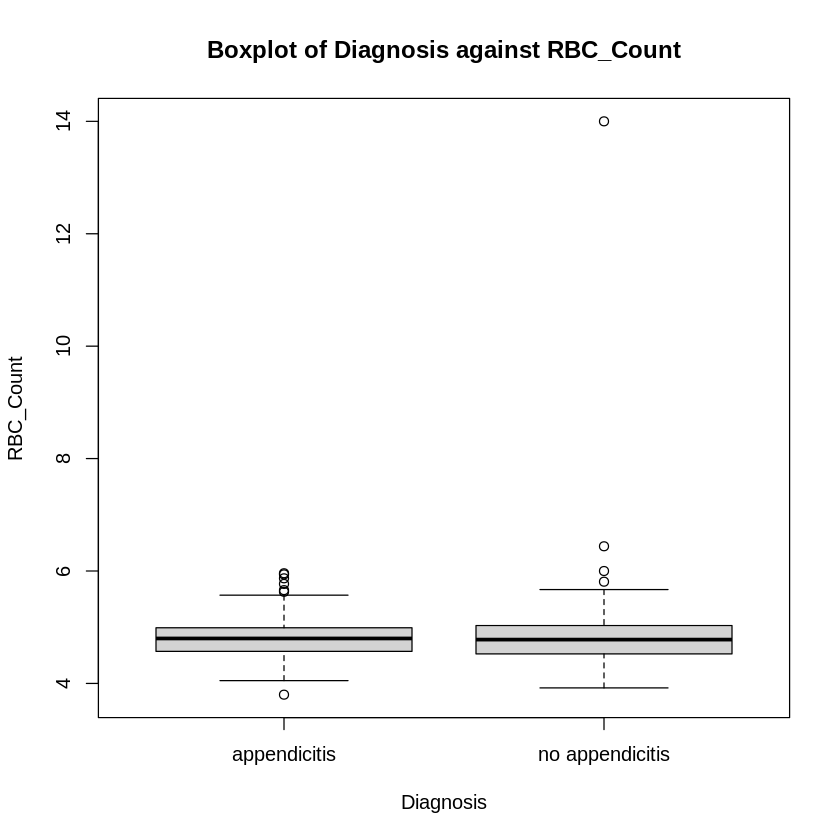

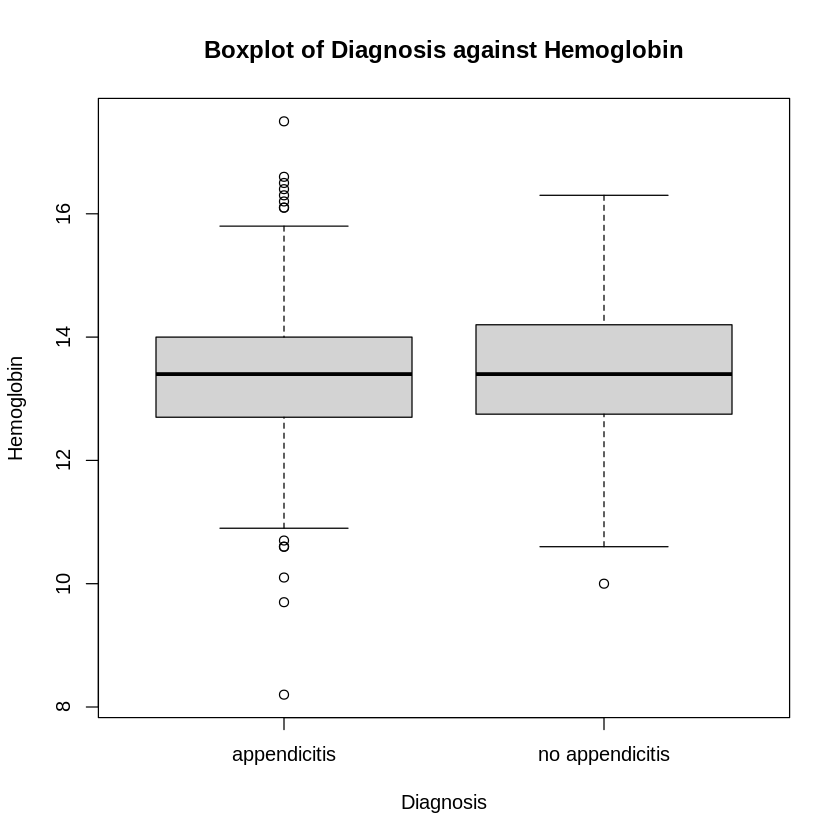

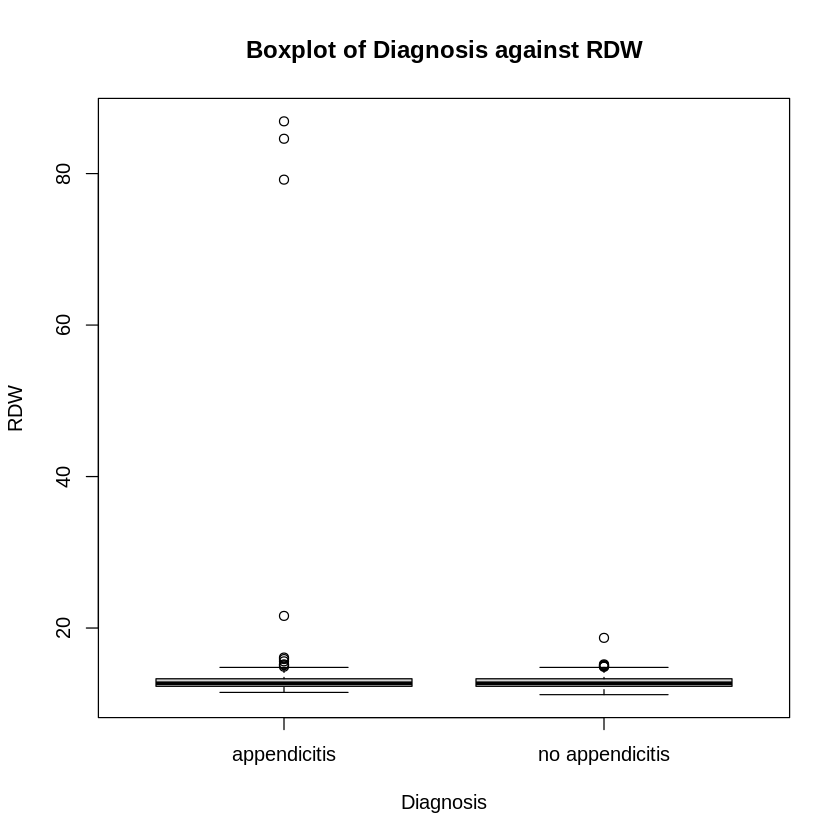

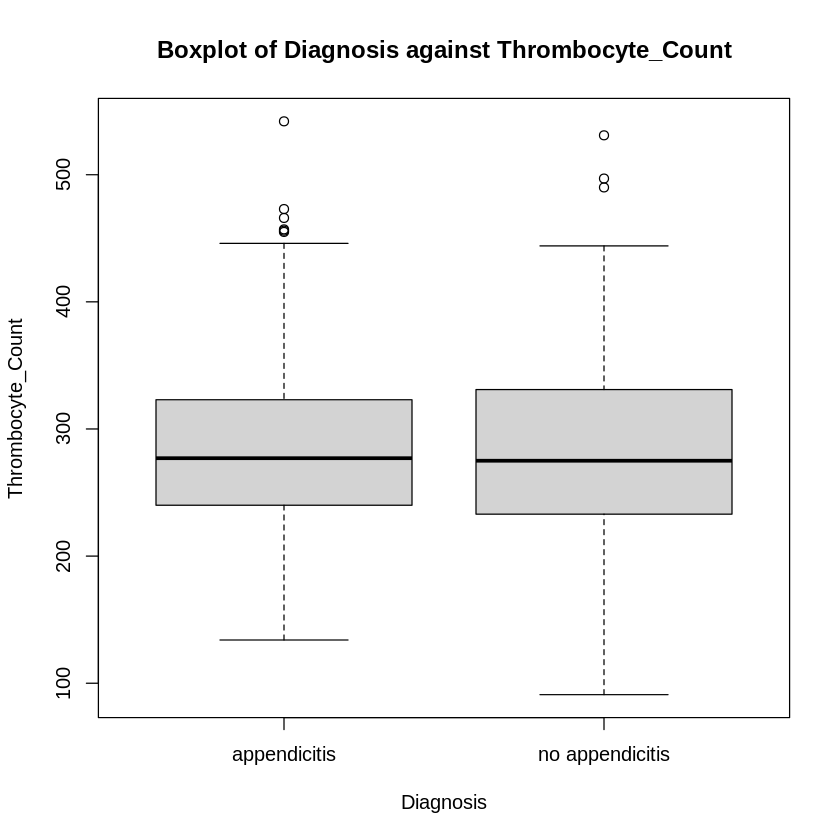

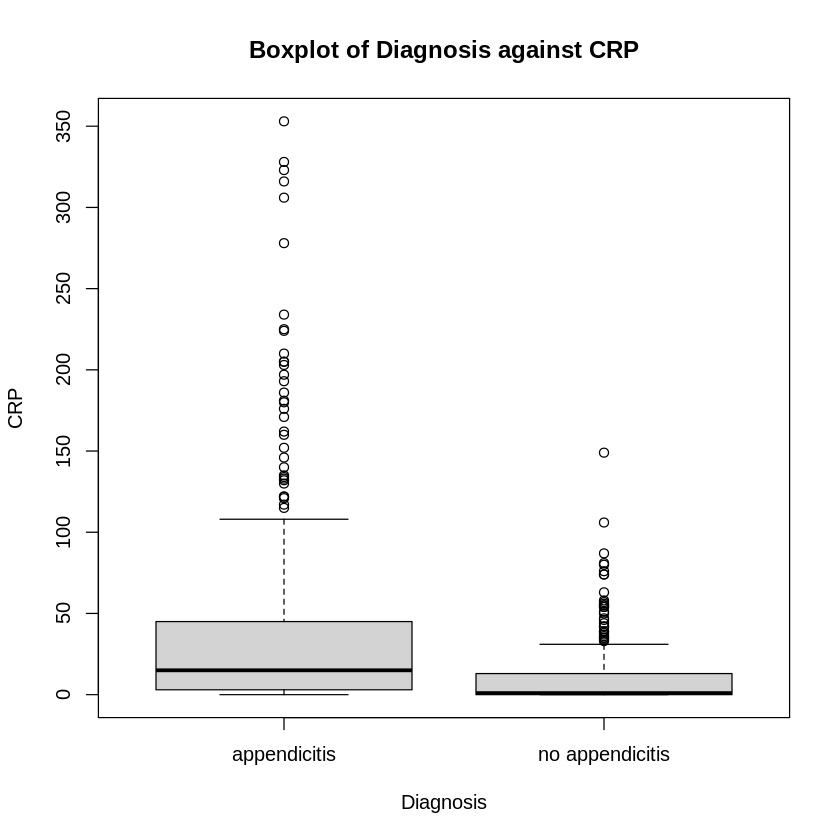

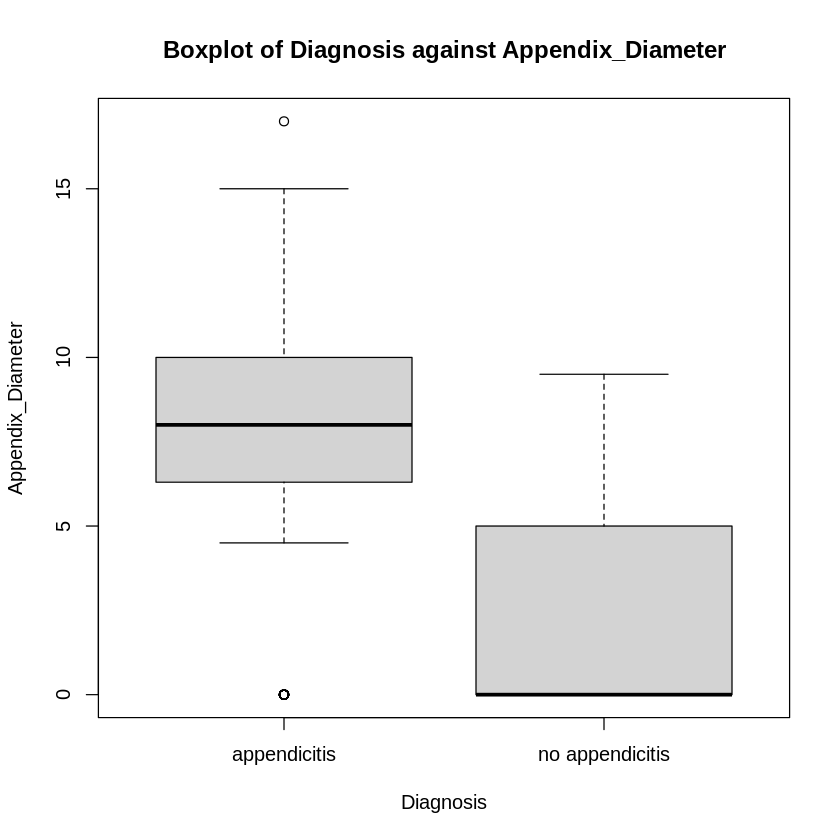

In [70]:
#Check for outlier
num <- unlist(lapply(df, is.numeric), use.names = FALSE)
for (y in names(df[num])) {
  boxplot(df[[y]] ~ df$Diagnosis,
  main=sprintf('Boxplot of Diagnosis against %s', y),
  ylab=y, xlab='Diagnosis')
}

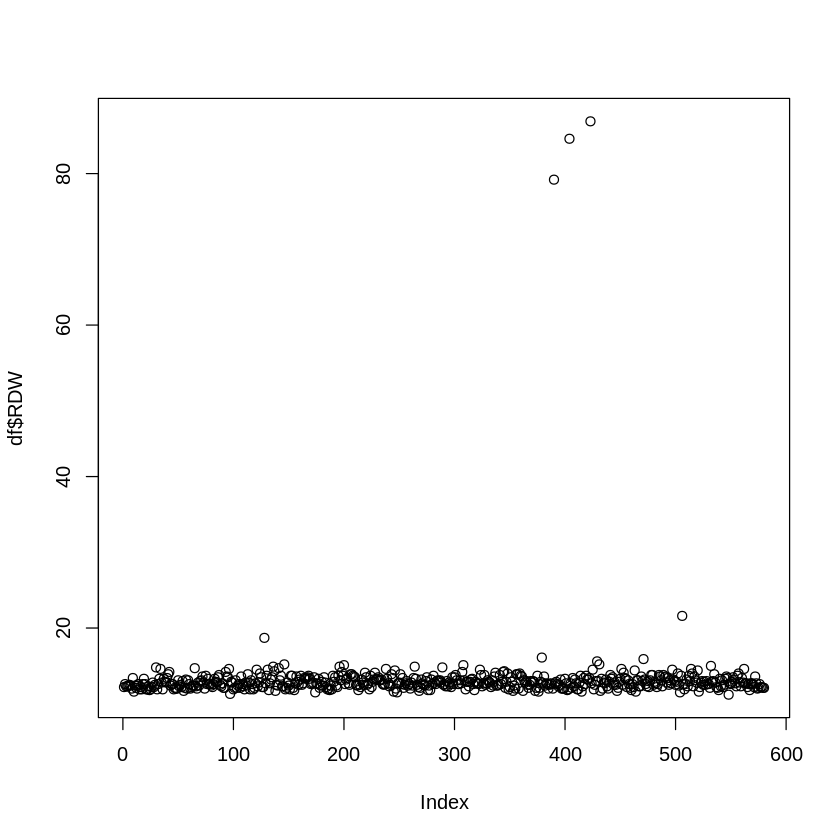

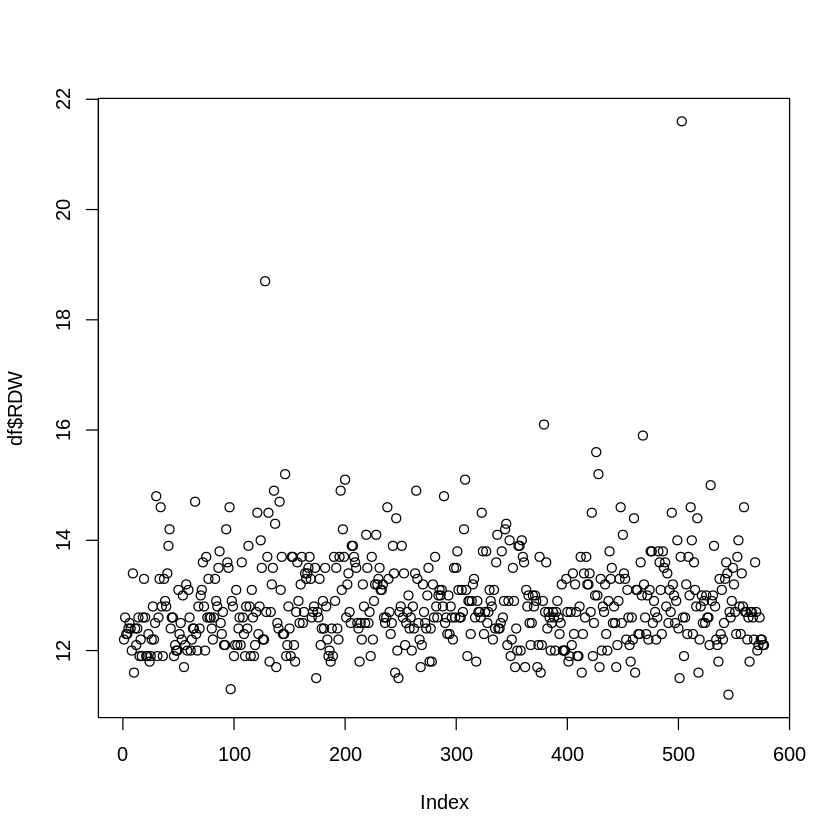

In [71]:
#Remove weird data points
plot(df$RDW)
for (x in 1:3) {
to_remove <- which(df$RDW == max(df$RDW))
df <- df[-to_remove,] }
plot(df$RDW)

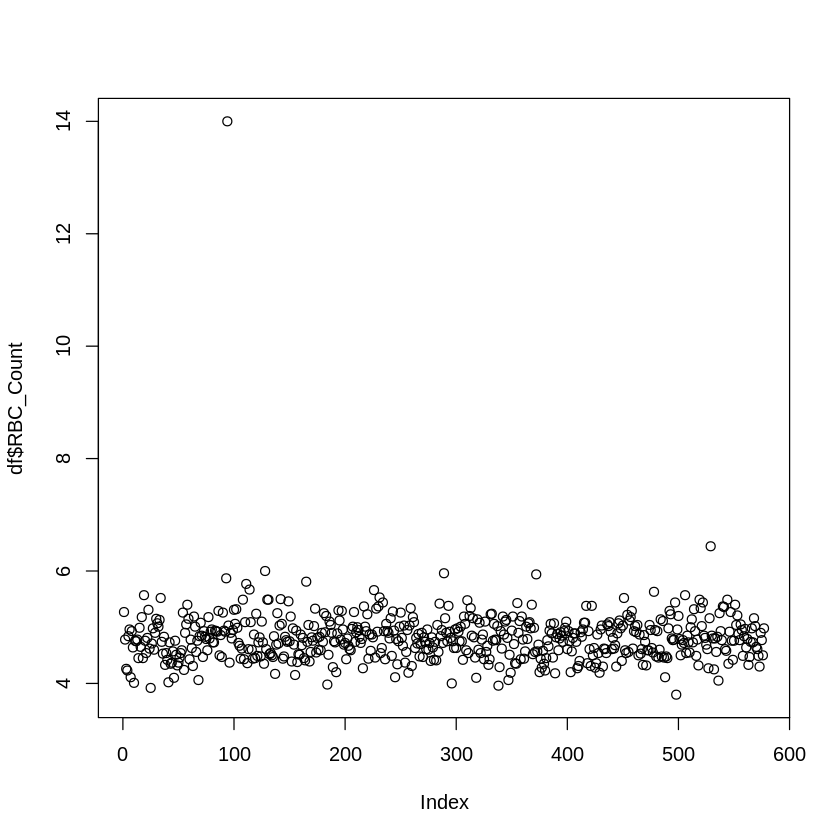

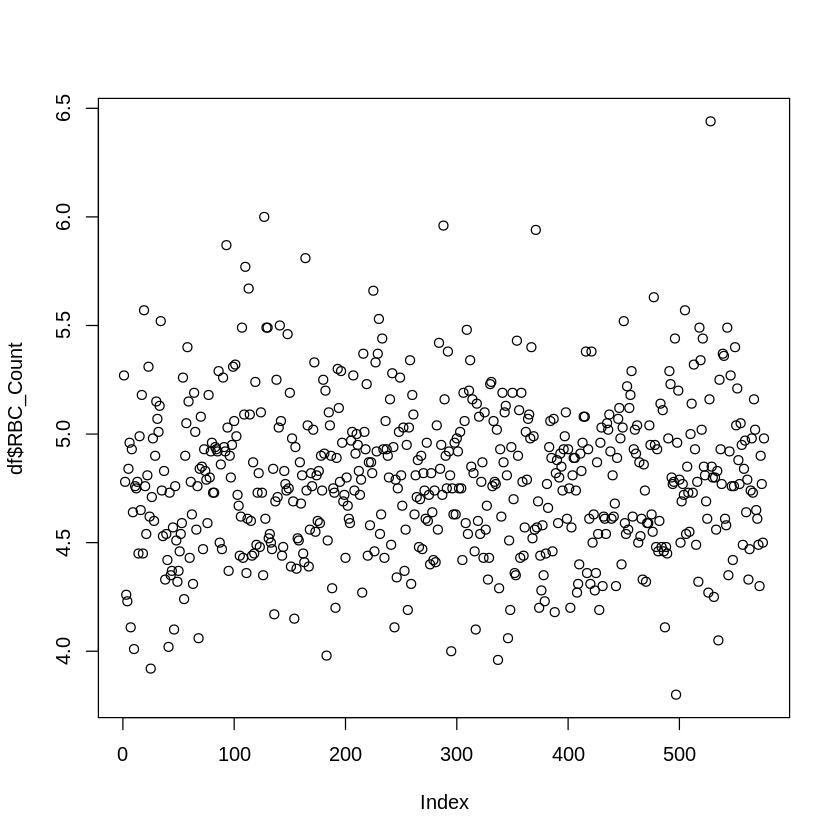

In [72]:
#Remove weird data points
plot(df$RBC_Count)
to_remove <- which(df$RBC_Count == max(df$RBC_Count))
df <- df[-to_remove,]
plot(df$RBC_Count)

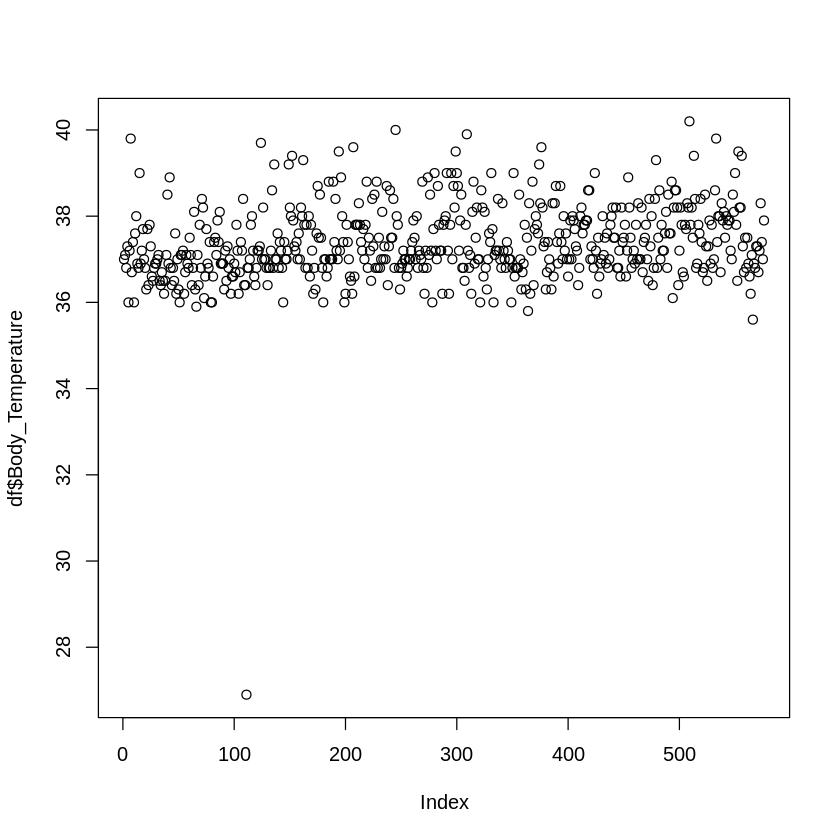

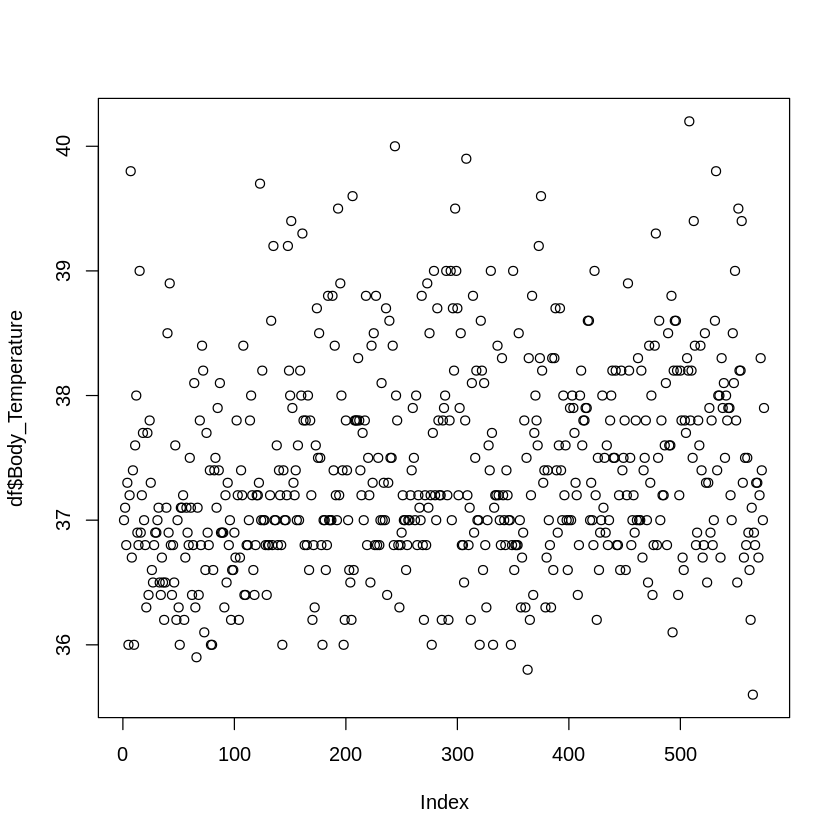

In [73]:
#Remove weird data points
plot(df$Body_Temperature)
to_remove <- which(df$Body_Temperature == min(df$Body_Temperature))
df <- df[-to_remove,]
plot(df$Body_Temperature)

In [74]:
#Split the data
set.seed(42)
library(rsample)
split <- initial_split(df, prop = 0.75, strata = Diagnosis)
train_data <- training(split)
test_data  <- testing(split)
table(train_data$Diagnosis)
table(test_data$Diagnosis)


   appendicitis no appendicitis 
            243             187 


   appendicitis no appendicitis 
             82              63 

In [75]:
#Add new column
train_data$Diagnosis01 <- ifelse(train_data$Diagnosis == "appendicitis", 1, 0)
test_data$Diagnosis01 <- ifelse(test_data$Diagnosis == "appendicitis", 1, 0)
train_data$Diagnosis01 <- as.factor(train_data$Diagnosis01)
test_data$Diagnosis01 <- as.factor(test_data$Diagnosis01)
str(train_data)

'data.frame':	430 obs. of  32 variables:
 $ Age                             : num  12.7 14.3 11.2 13 14.7 ...
 $ BMI                             : num  16.9 14.9 14.9 20.2 18.5 23.5 16.5 12.9 16.7 14.8 ...
 $ Sex                             : Factor w/ 2 levels "female","male": 1 2 2 1 1 2 2 1 2 2 ...
 $ Height                          : num  148 174 142 159 174 ...
 $ Weight                          : num  37 45.5 30 51 56 49.5 26.5 26 36.5 25 ...
 $ Management                      : Factor w/ 4 levels "conservative",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Severity                        : Factor w/ 2 levels "complicated",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ Diagnosis                       : Factor w/ 2 levels "appendicitis",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Alvarado_Score                  : int  4 4 6 7 8 4 5 6 5 8 ...
 $ Paedriatic_Appendicitis_Score   : int  3 4 6 5 7 3 5 5 4 7 ...
 $ Appendix_on_US                  : Factor w/ 2 levels "no","yes": 2 2 2 2 2 2 2 2 2 2 ...
 $ Migratory_Pain          

In [76]:
#Preparing data
fac <- unlist(lapply(train_data, is.factor), use.names = FALSE)
num <- unlist(lapply(train_data, is.numeric), use.names = FALSE)
num_test <- unlist(lapply(test_data, is.numeric), use.names = FALSE)

In [77]:
scaled_train <- scale(train_data[num])
train_mean <- attr(scaled_train, "scaled:center")
train_sd <- attr(scaled_train, "scaled:scale")
train_data[num] <- scale(train_data[num], center=train_mean, scale=train_sd)
test_data[num] <- scale(test_data[num], center=train_mean, scale=train_sd)

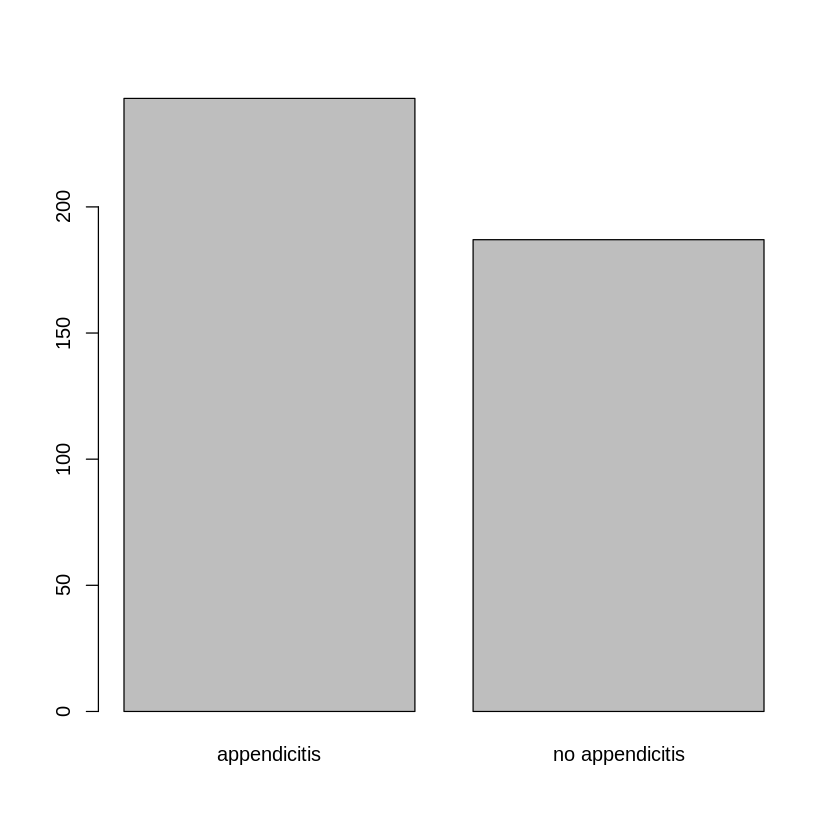

In [78]:
#Basic EDA
plot(train_data$Diagnosis)
#Pretty balanced

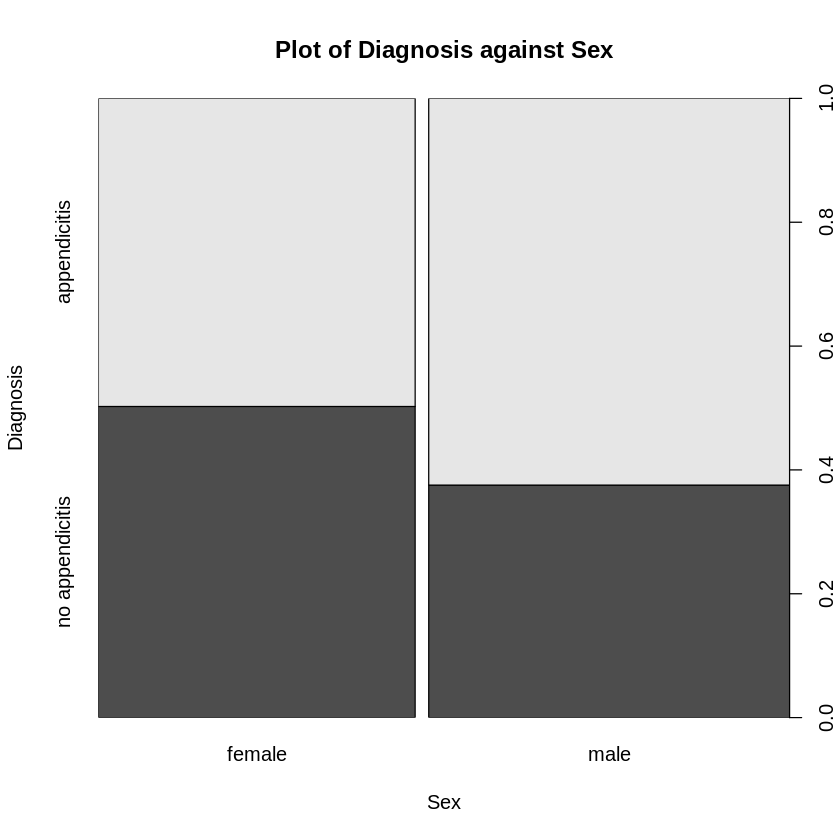

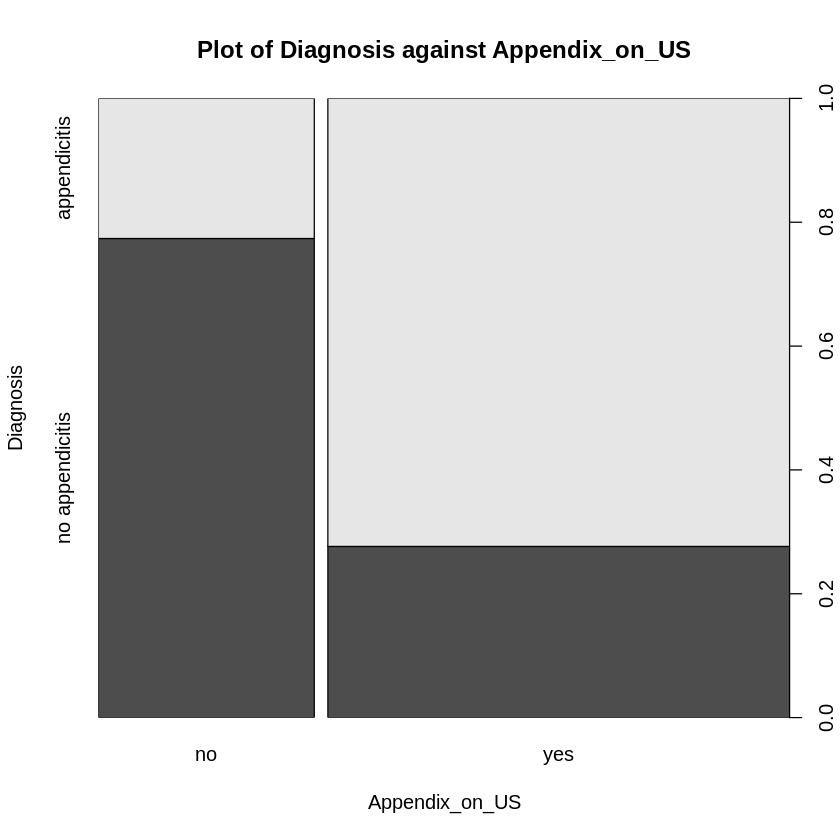

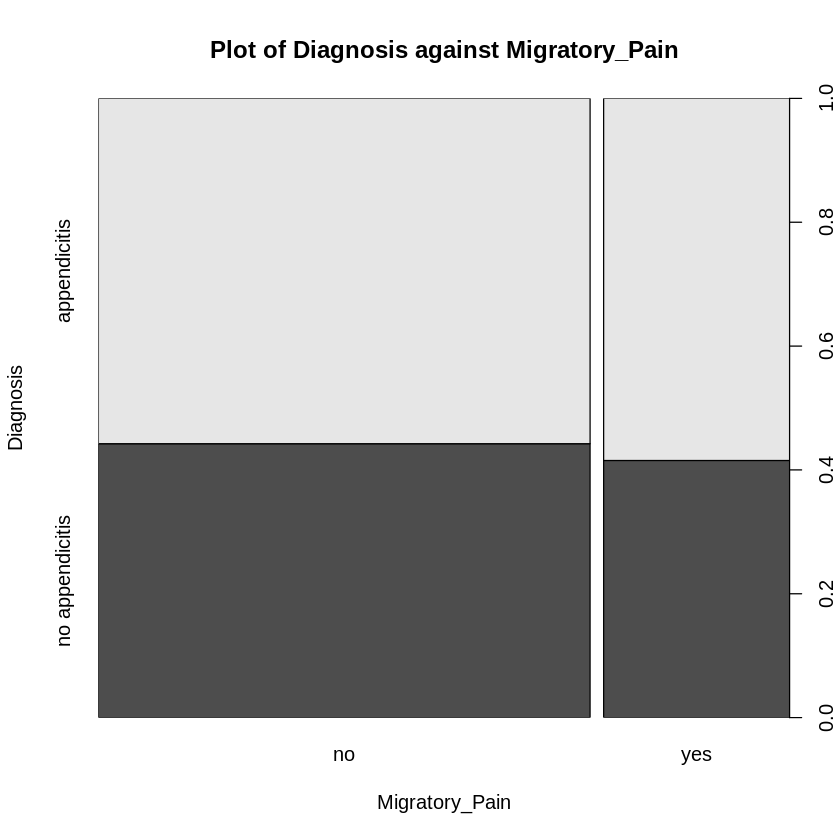

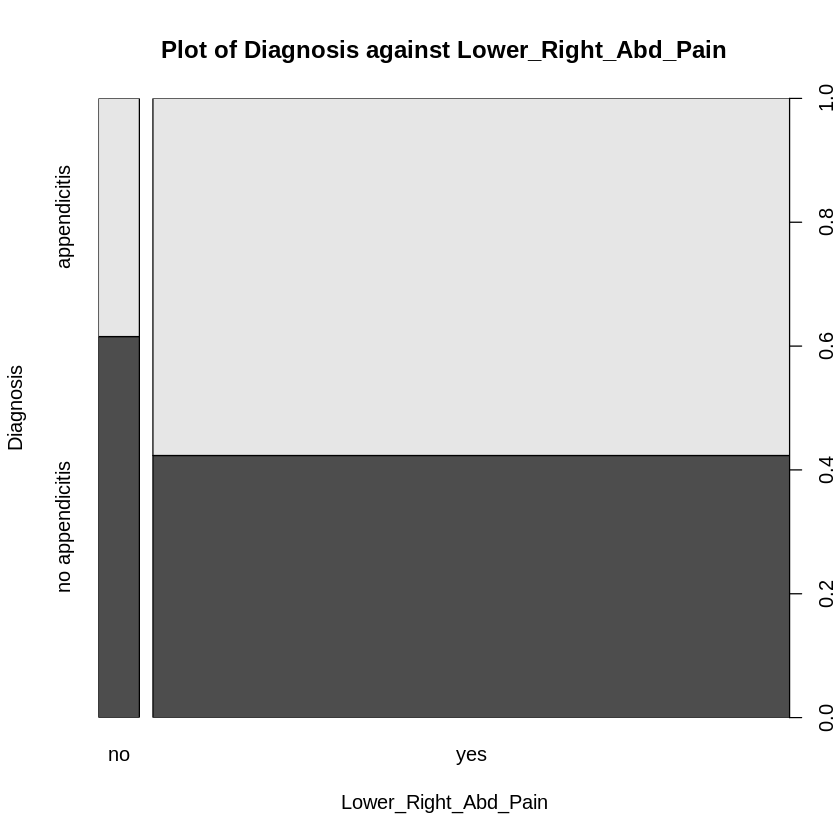

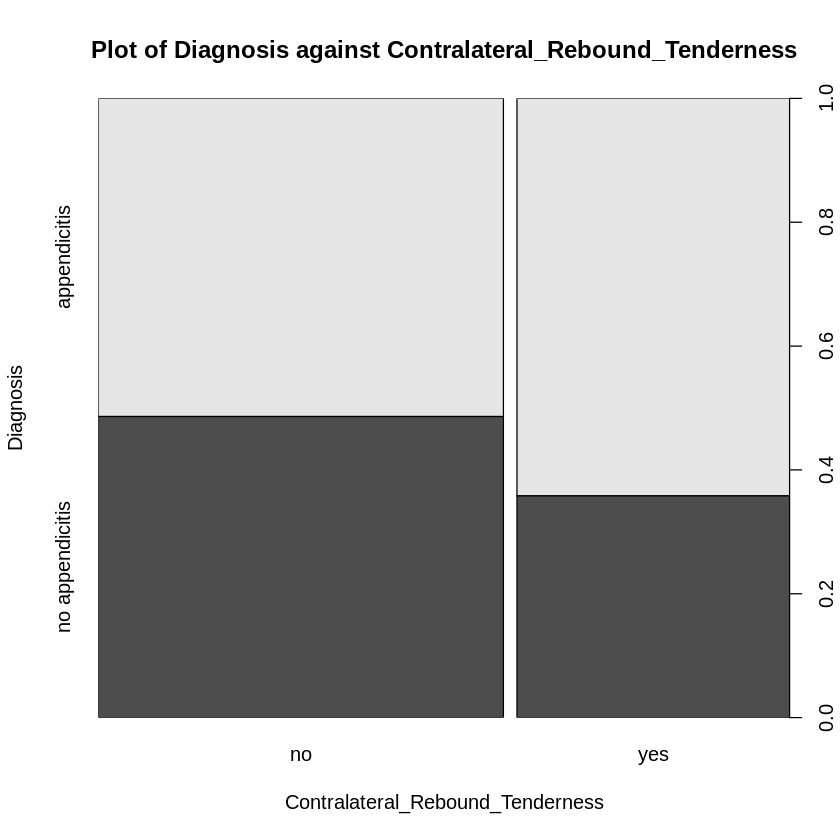

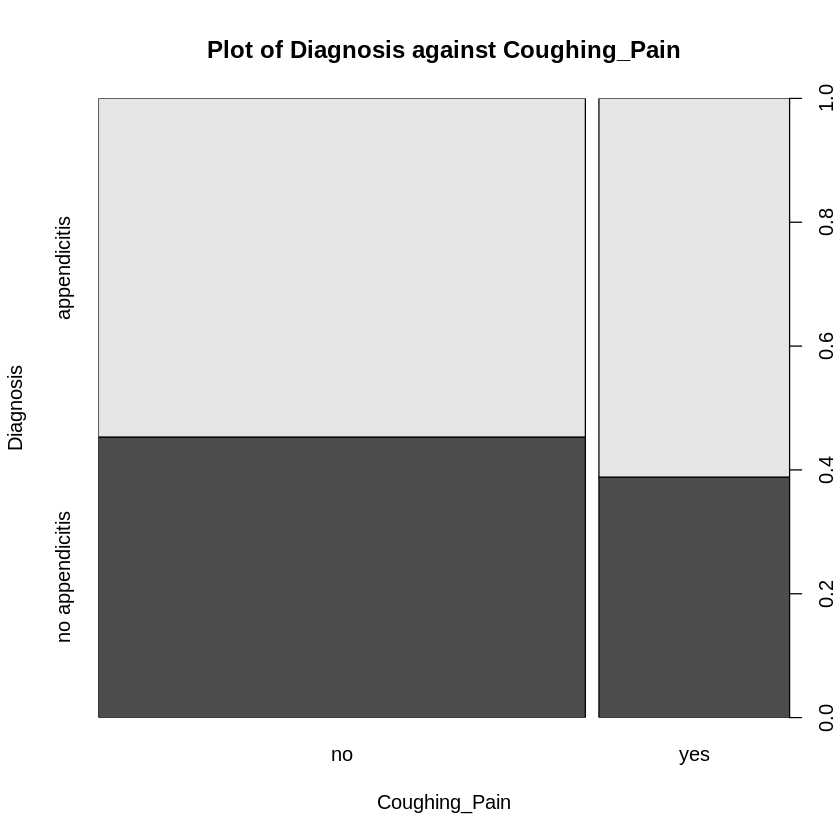

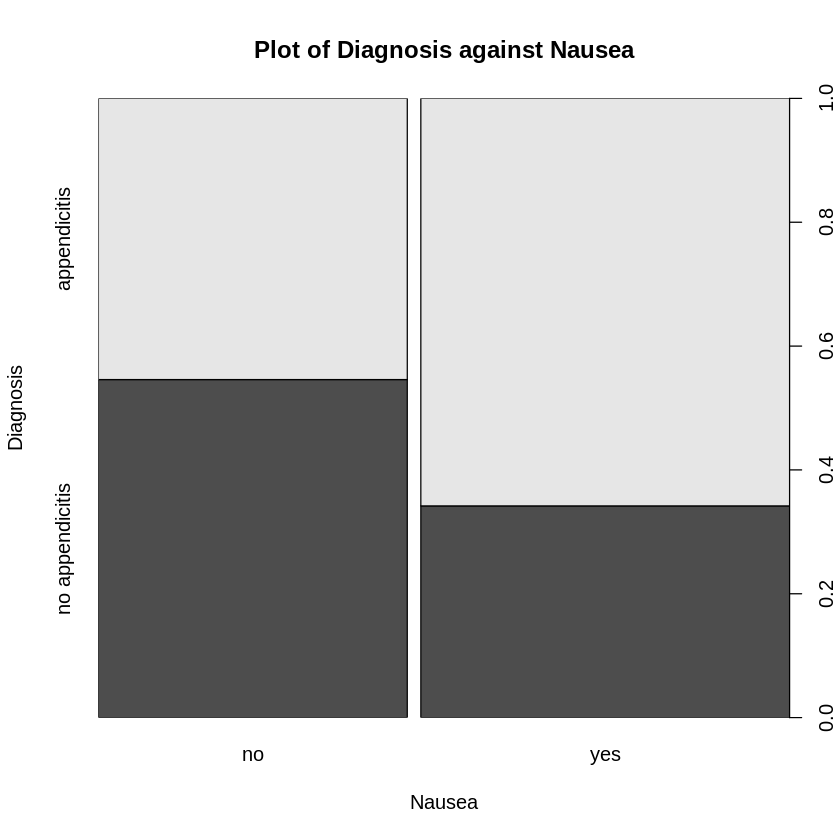

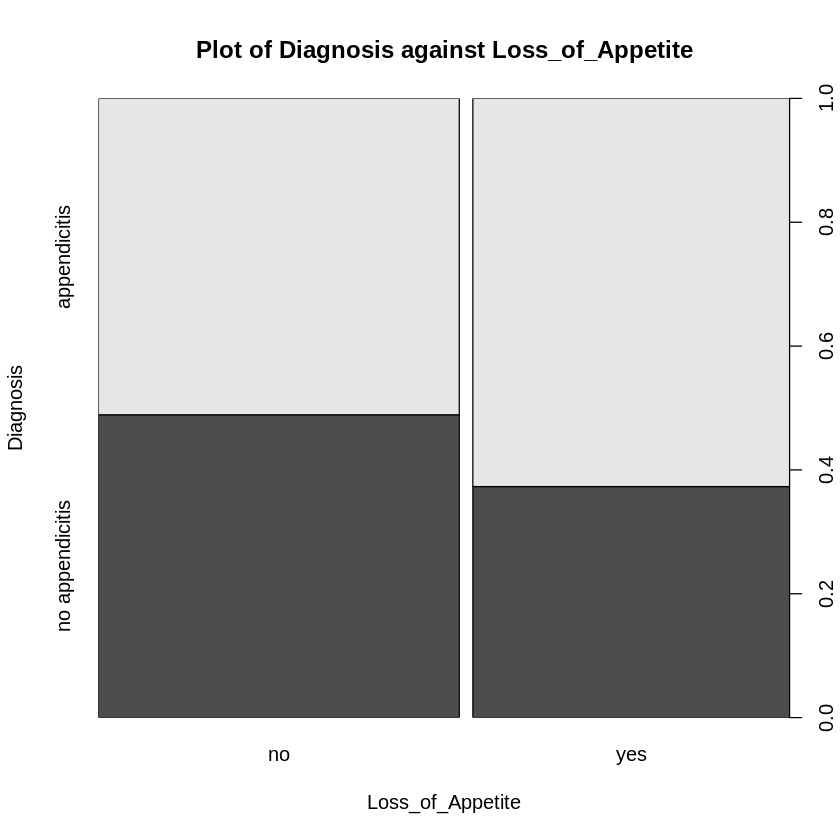

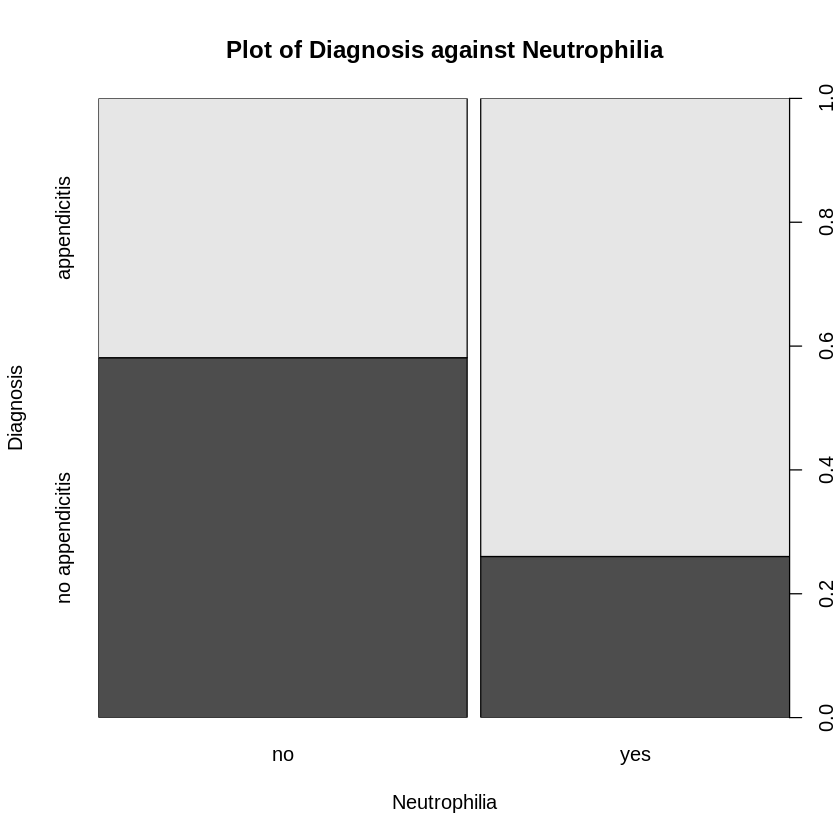

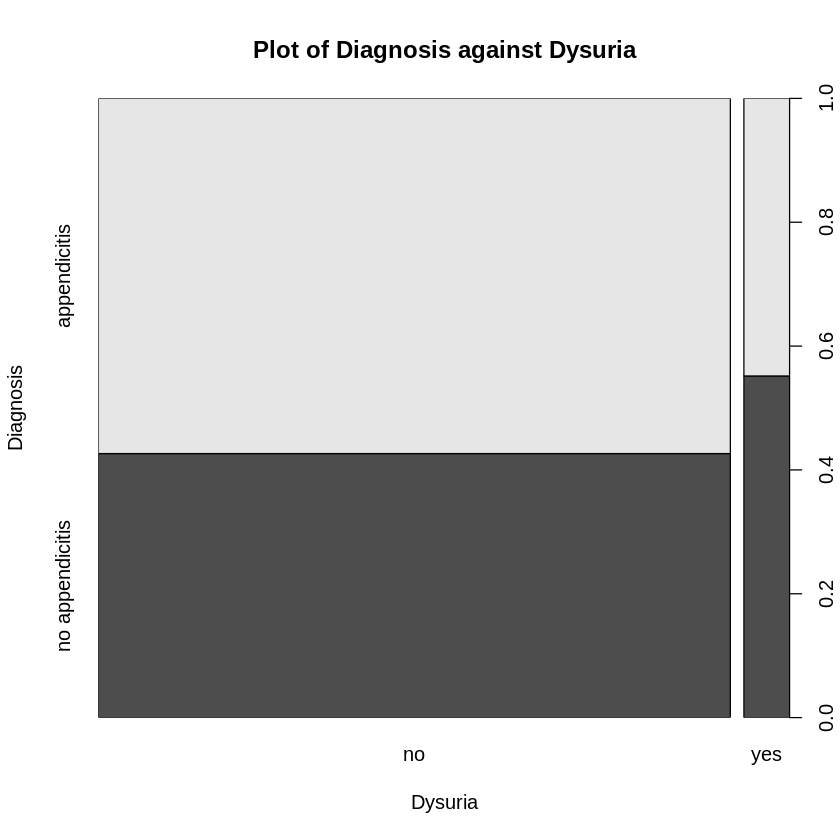

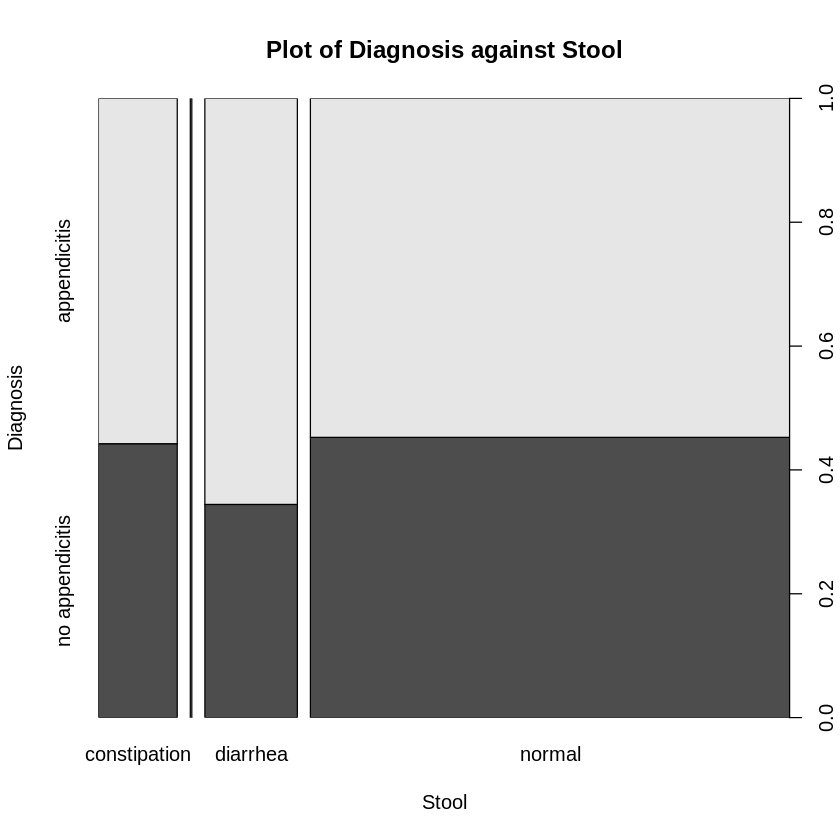

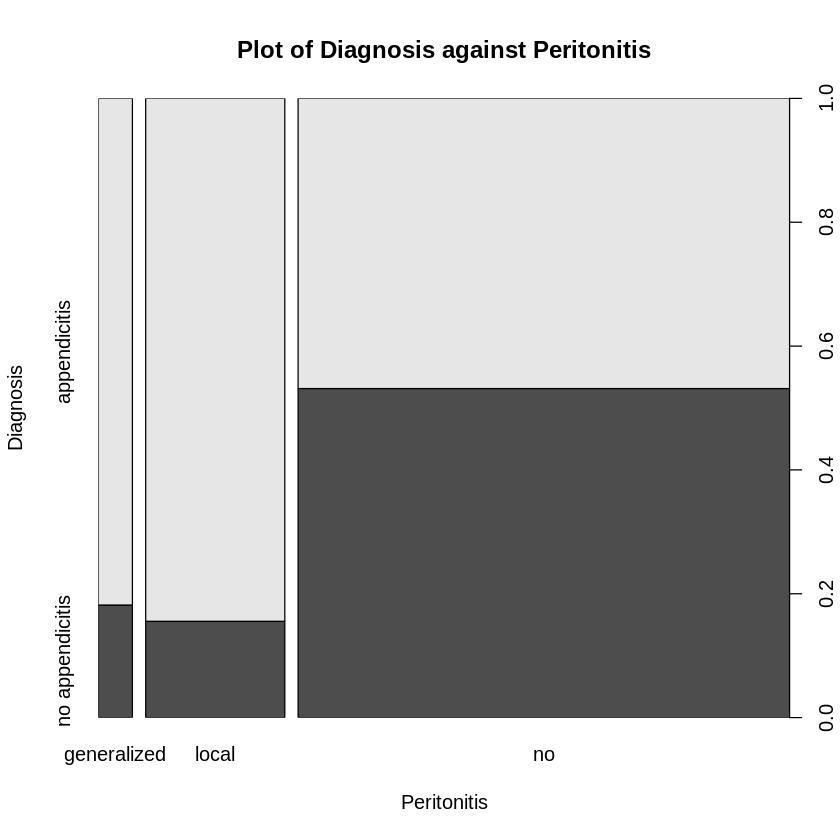

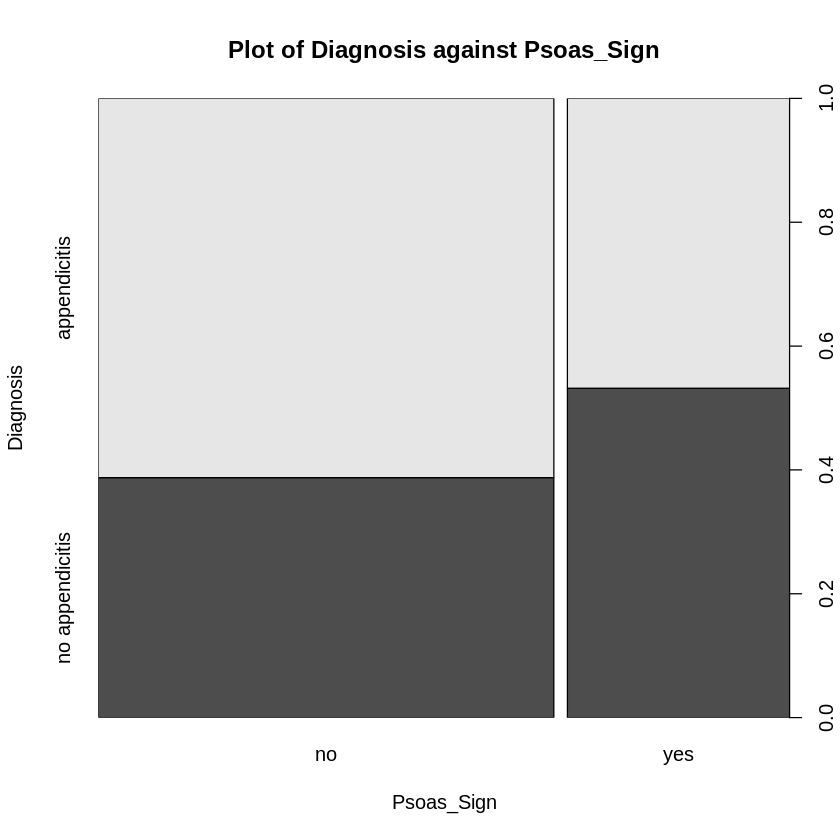

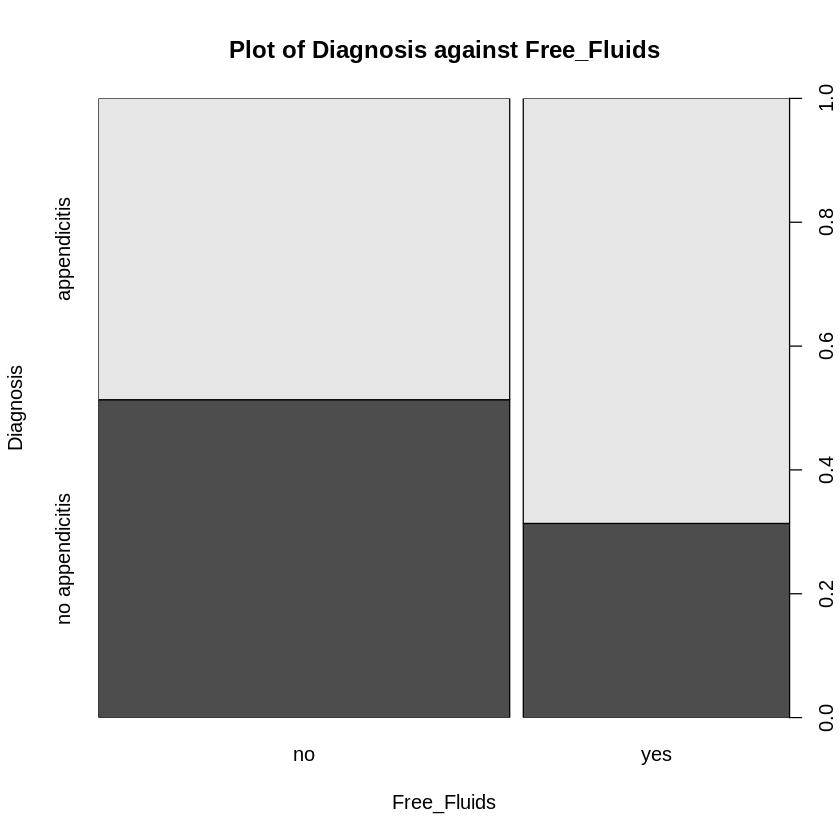

In [79]:
for (x in names(train_data[fac][,!names(train_data[fac]) %in% c('Severity','Management','Diagnosis','Diagnosis01')])) {
  plot(x=train_data[[x]], y=train_data$Diagnosis,
  main=sprintf('Plot of Diagnosis against %s', x),
  xlab=x, ylab='Diagnosis')
}
#Some imbalance in the data

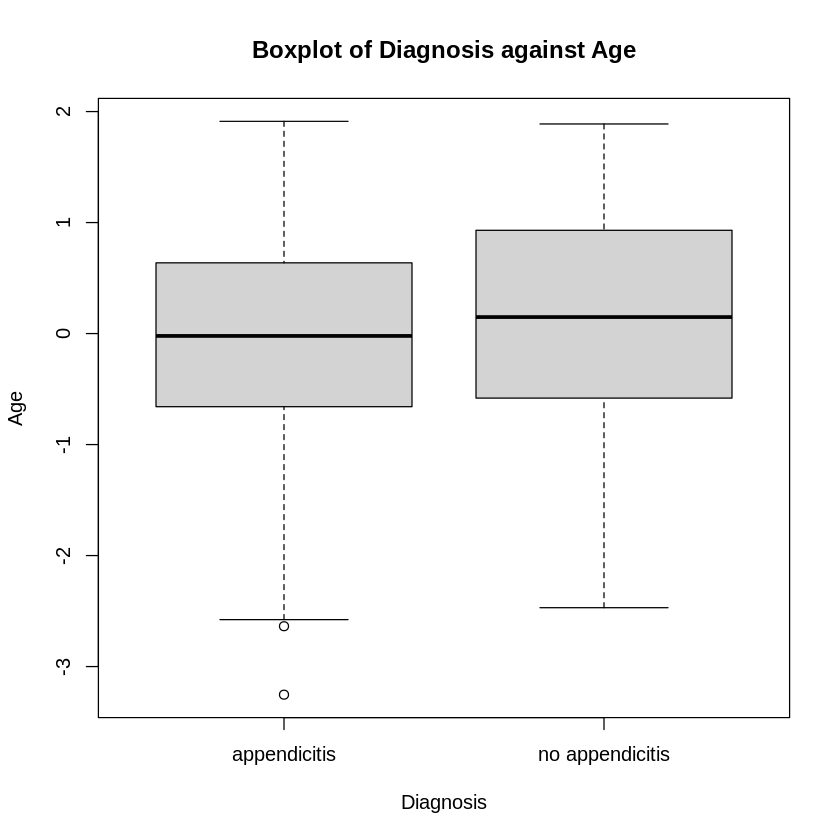

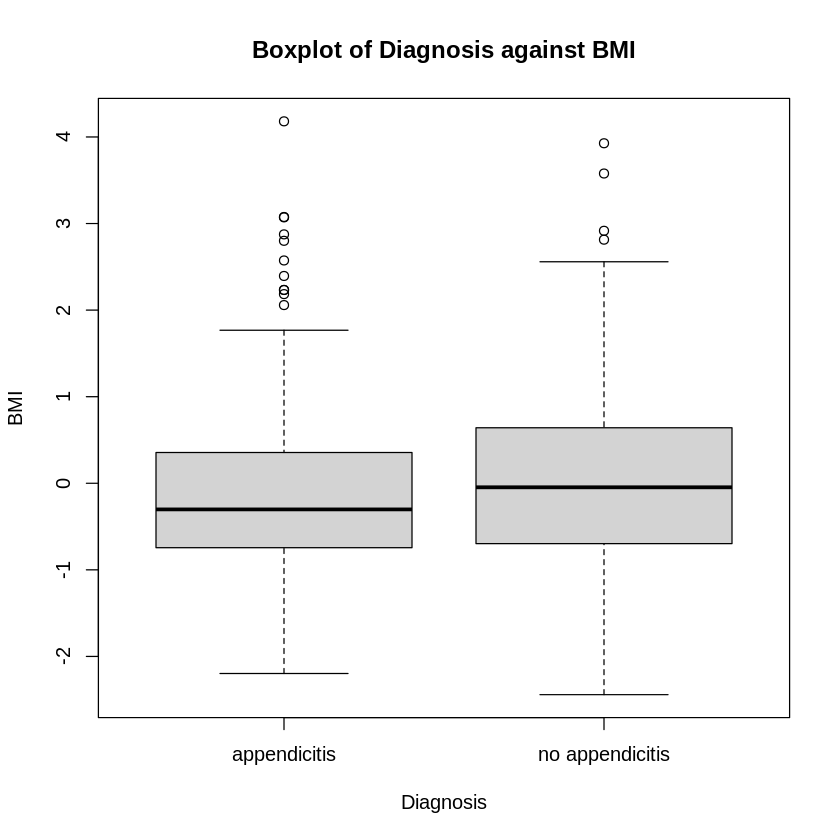

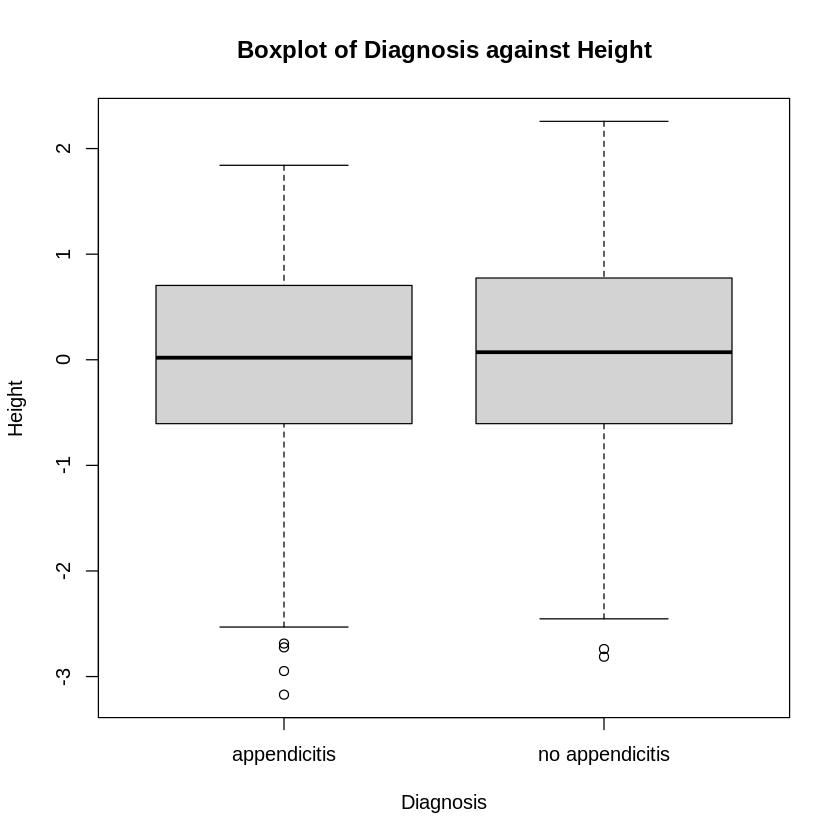

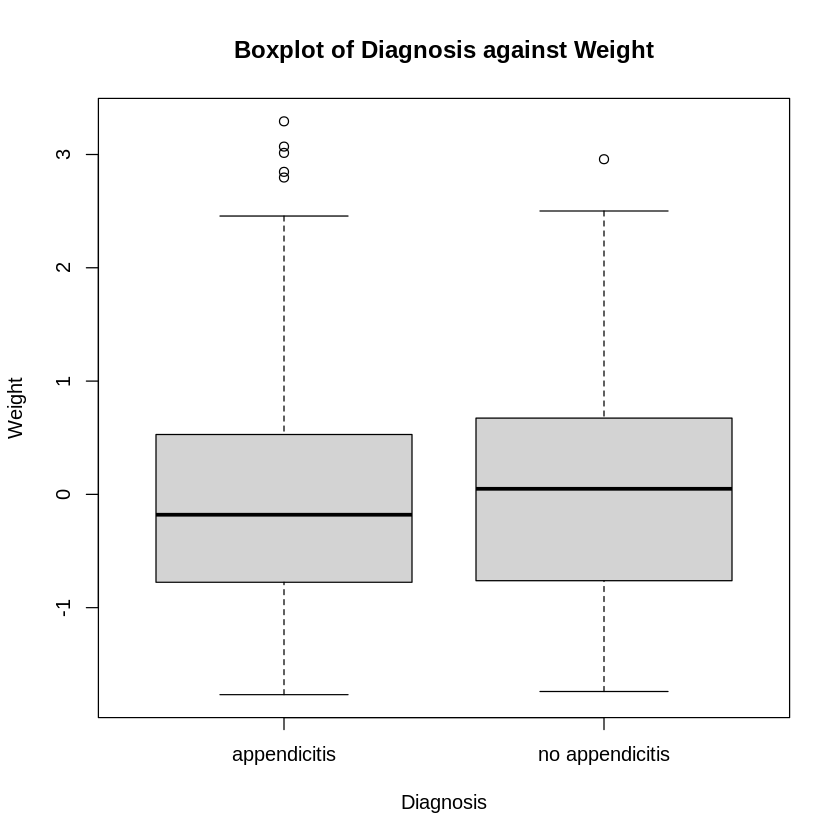

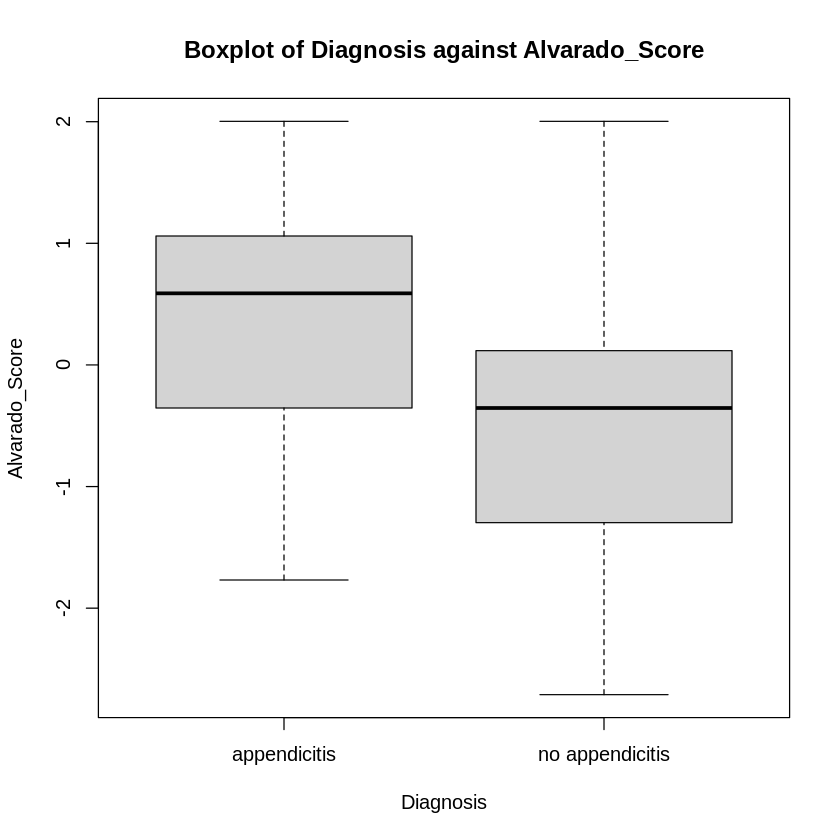

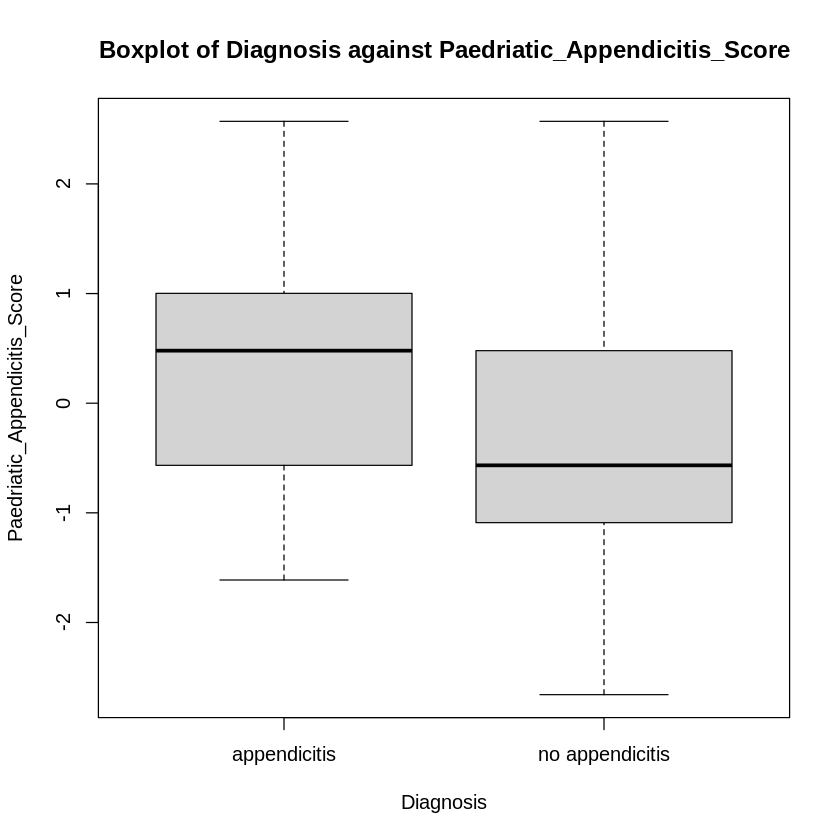

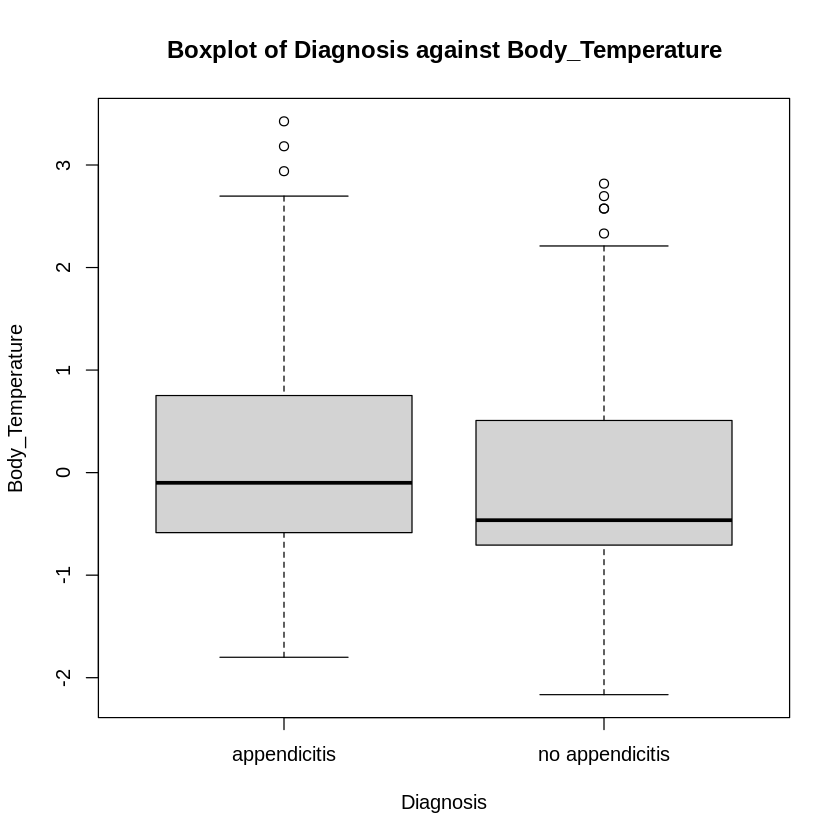

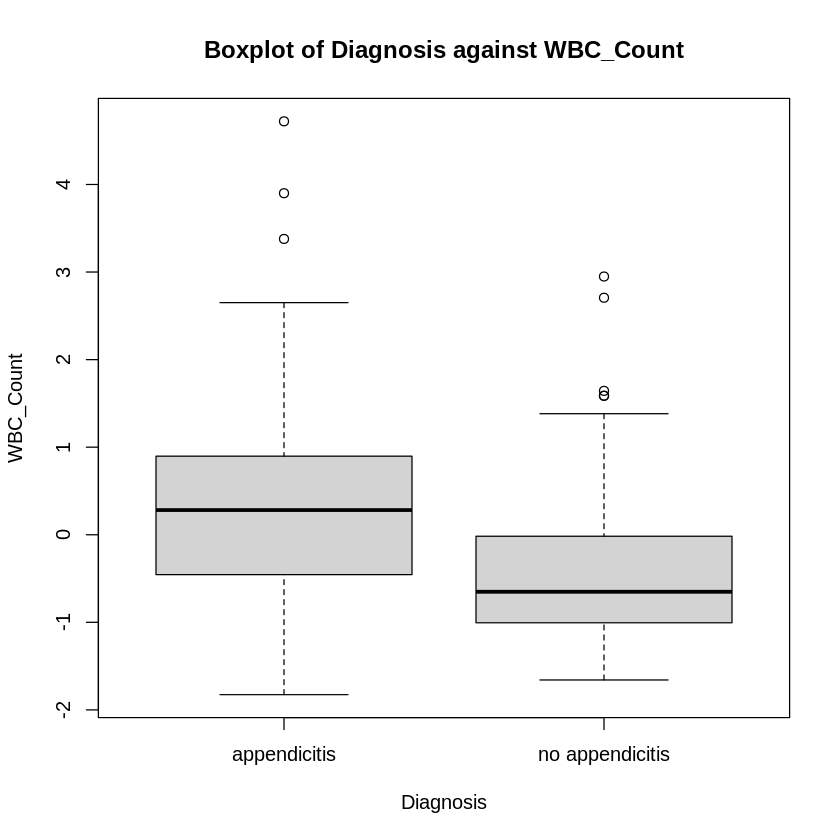

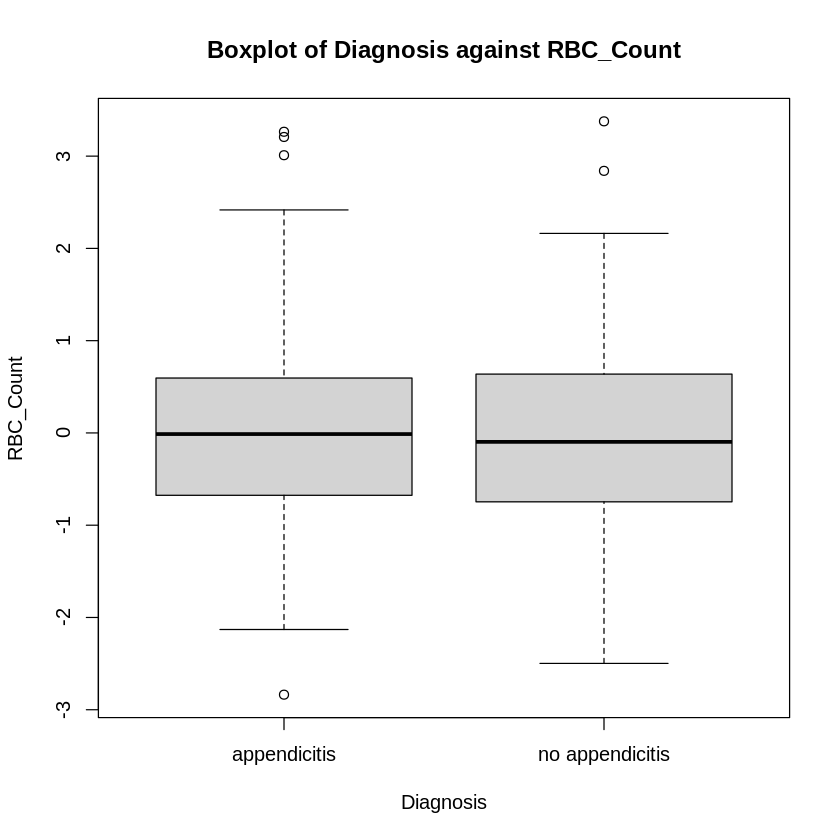

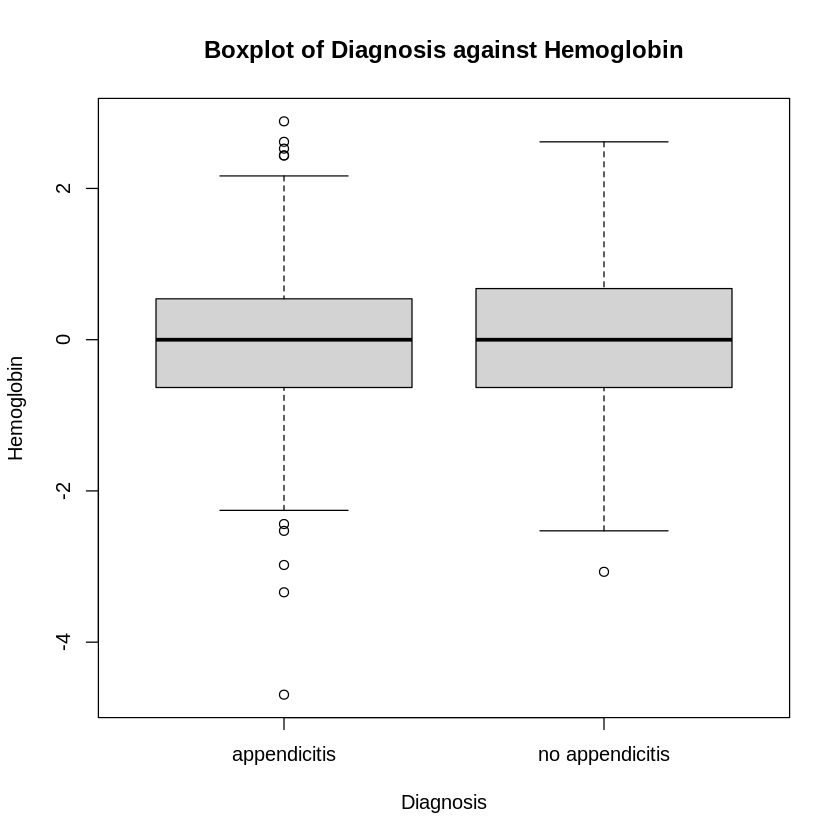

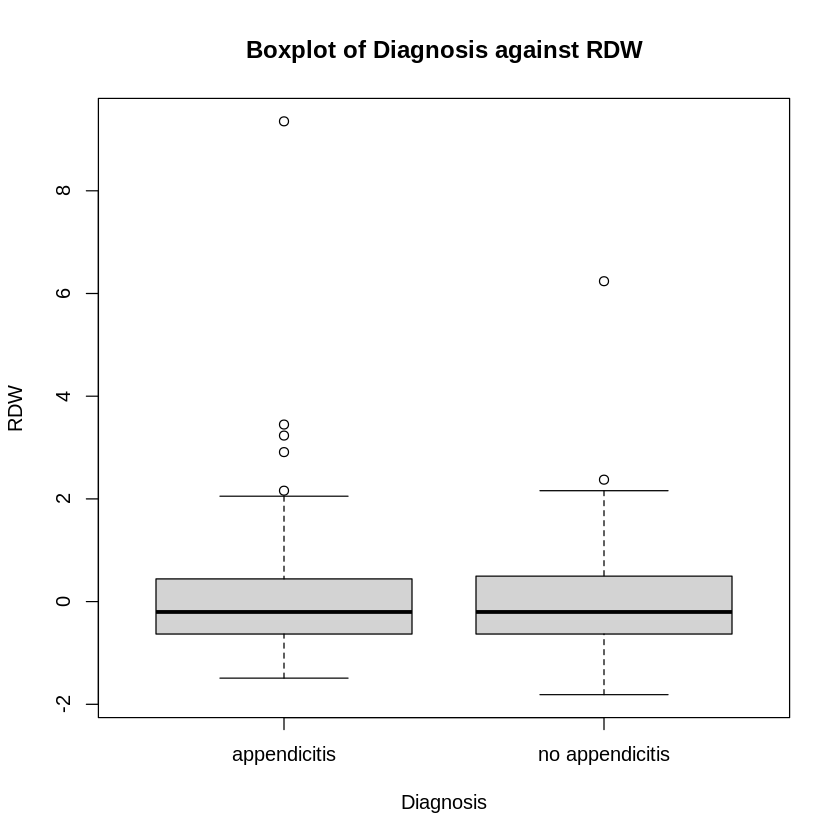

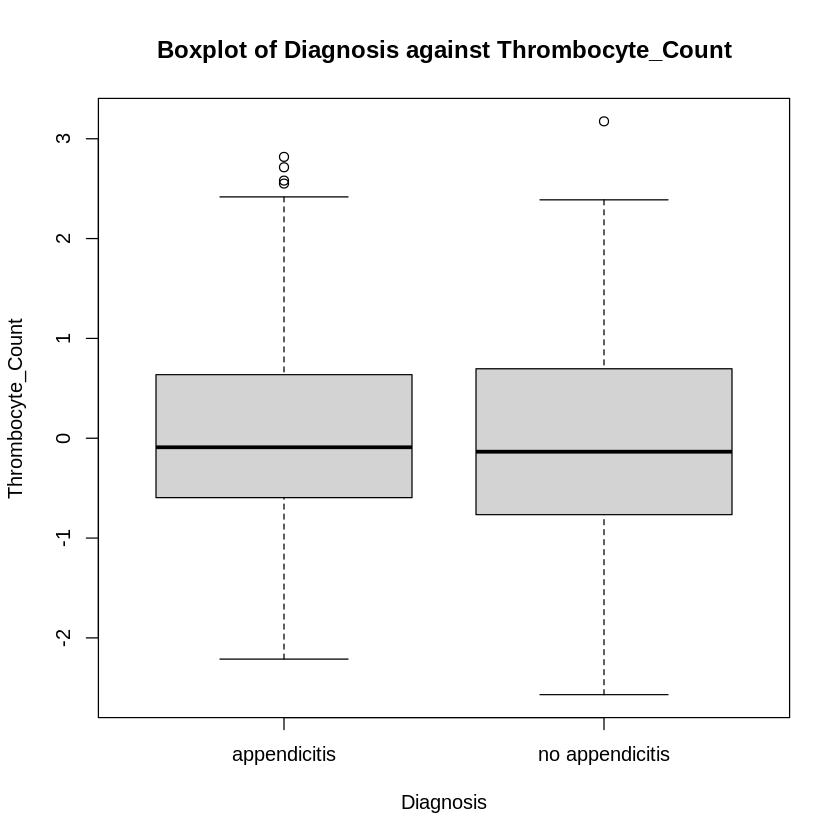

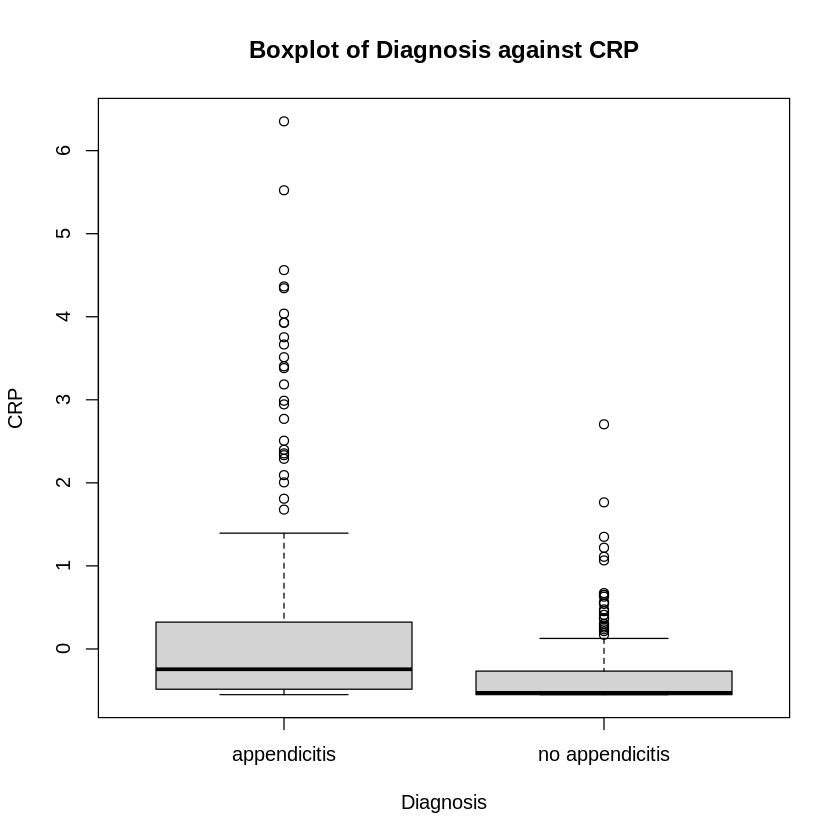

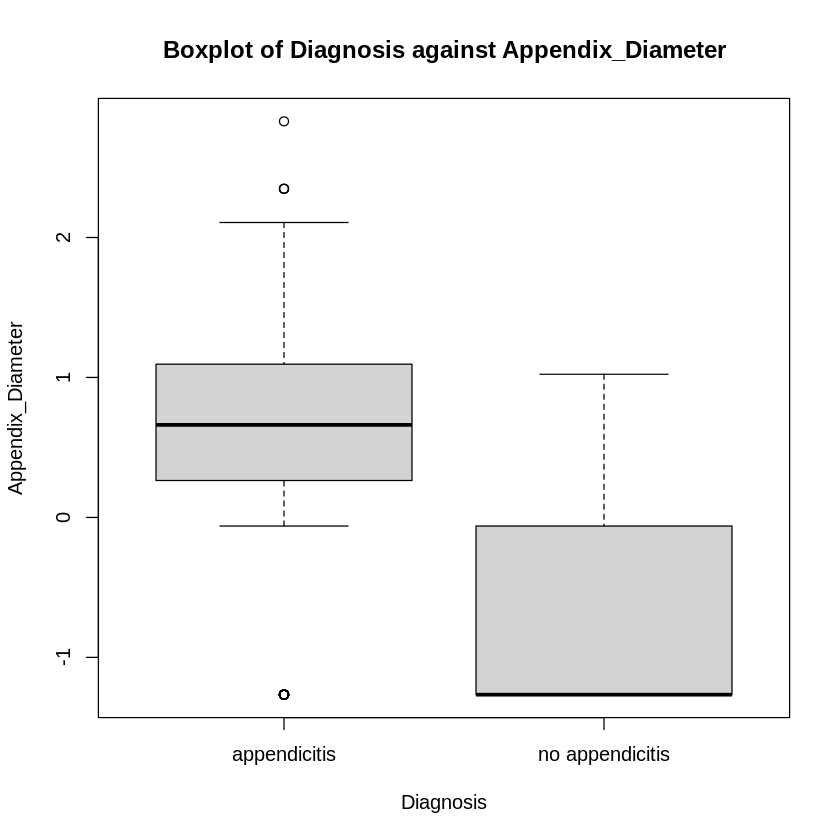

In [80]:
for (y in names(df[num])) {
  boxplot(train_data[[y]] ~ train_data$Diagnosis,
  main=sprintf('Boxplot of Diagnosis against %s', y),
  ylab=y, xlab='Diagnosis')
}
#I saw some very helpful patterns
#Also some outlier

In [81]:
logitplot<-function(y,x,ncat=10,...)
{
  y<-y[!is.na(x)]
  x<-x[!is.na(x)]
  brksx<-unique(quantile(x,probs=(0:ncat)/ncat))
  nbrksx<-length(brksx)
  cutx<-cut(x,breaks=brksx,include.lowest=TRUE)
  yt<-table(data.frame(y,cutx))
  mx<-tapply(x,cutx,FUN=mean)
  logity<-log((yt[2,]+0.5)/(yt[1,]+0.5))
  plot(mx,logity,...)
}

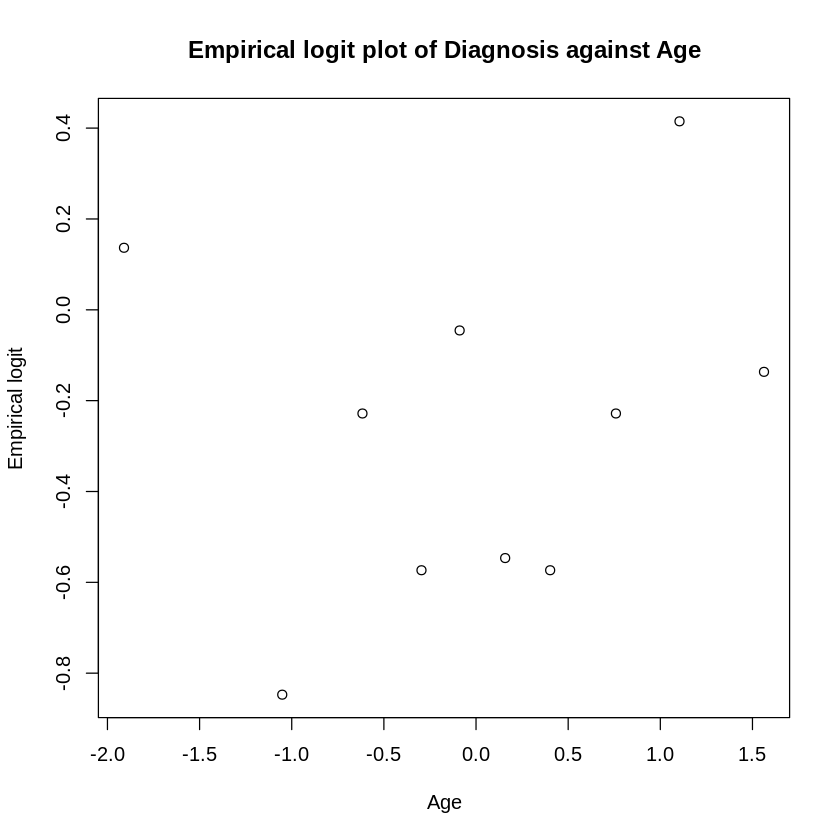

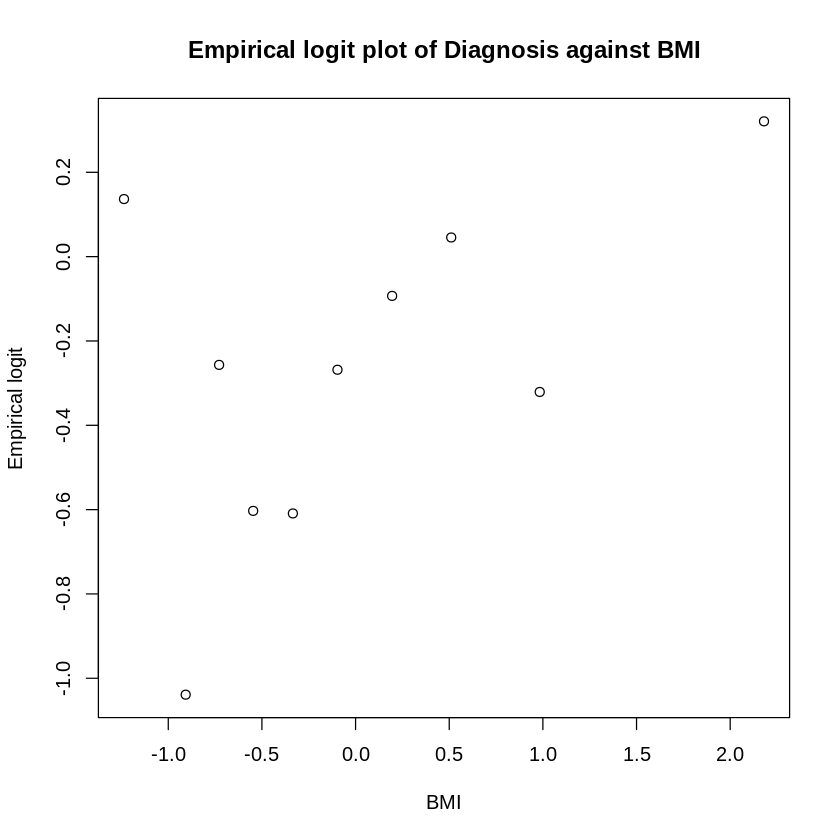

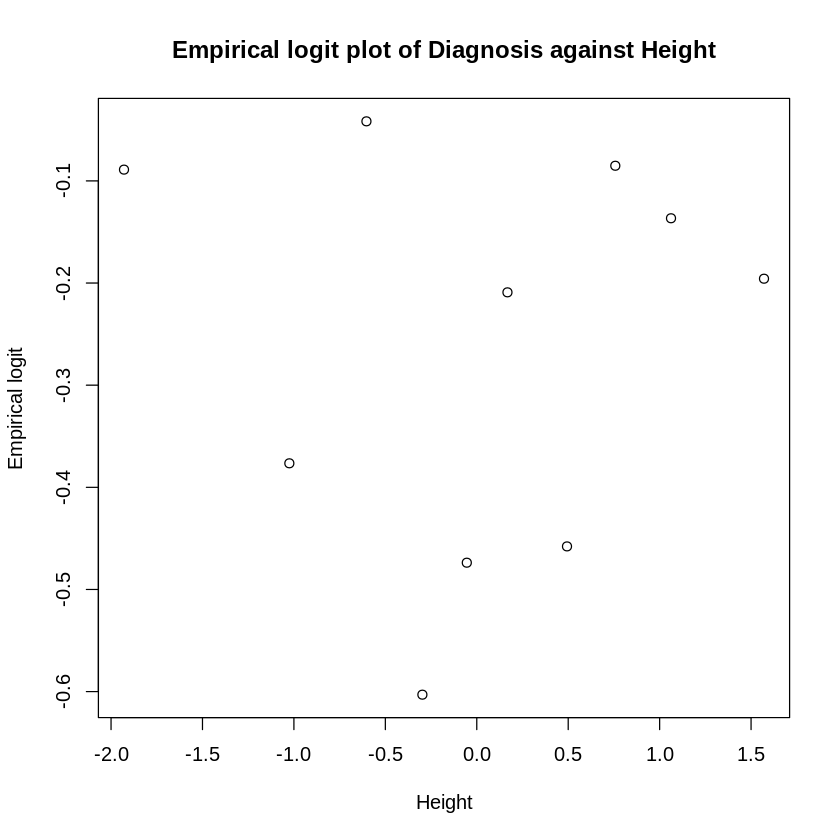

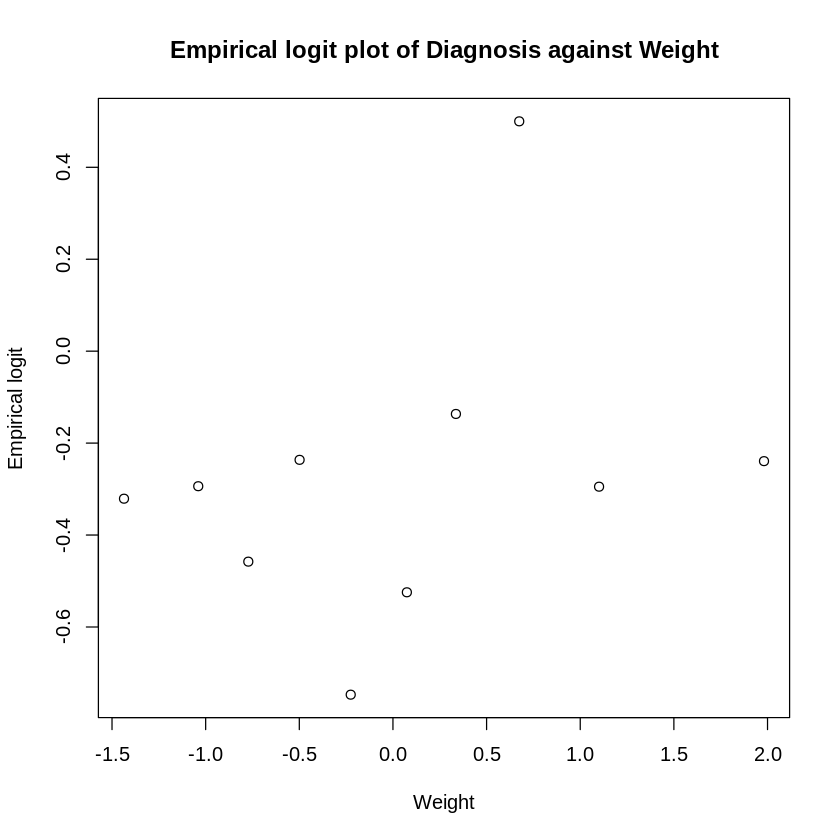

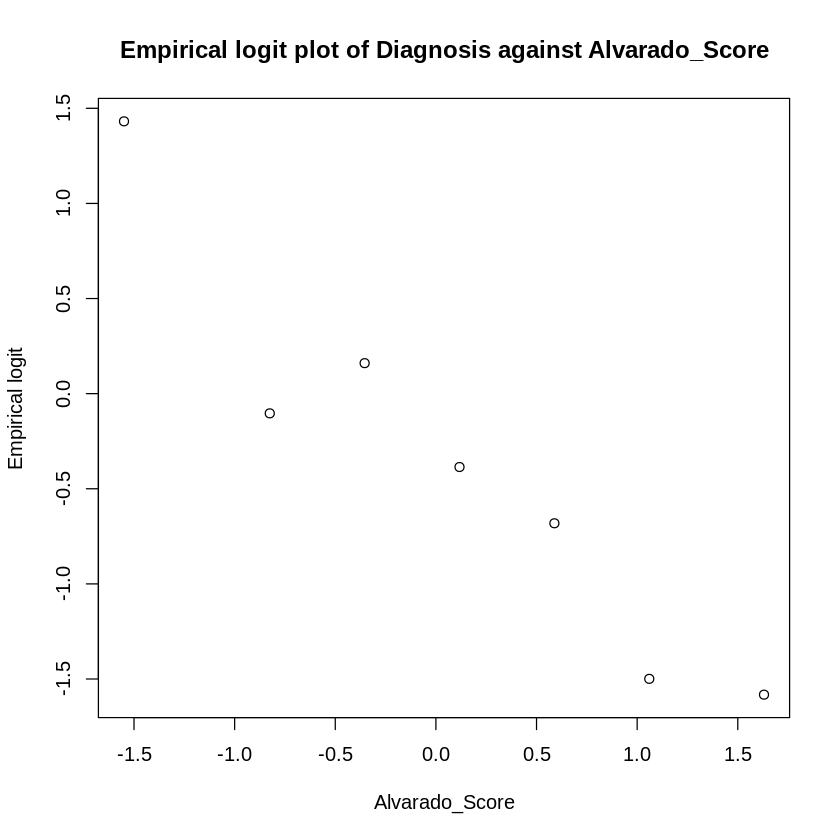

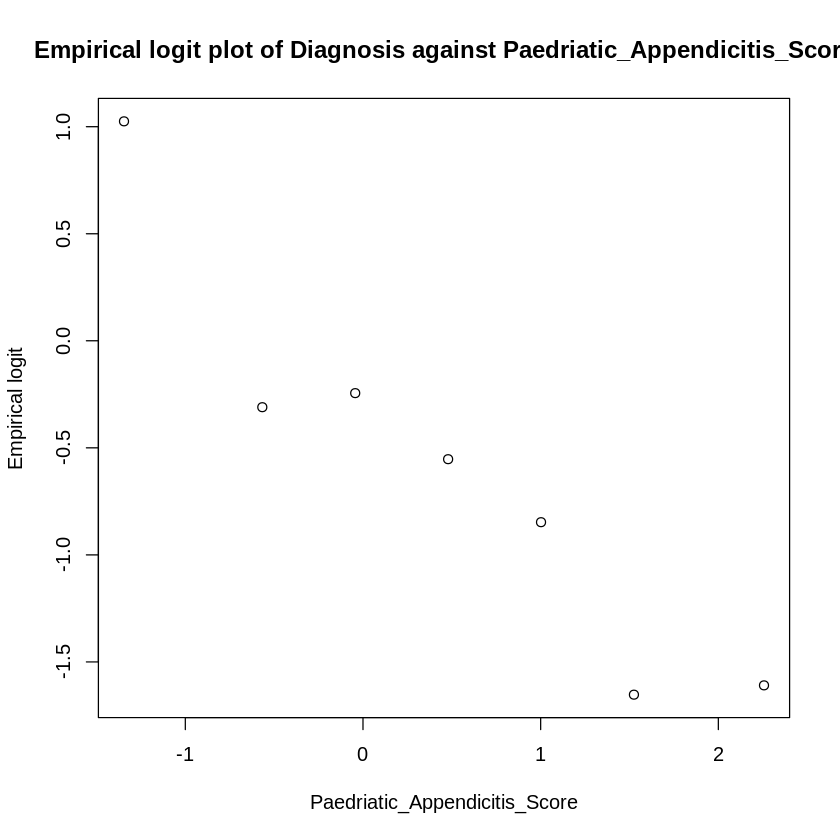

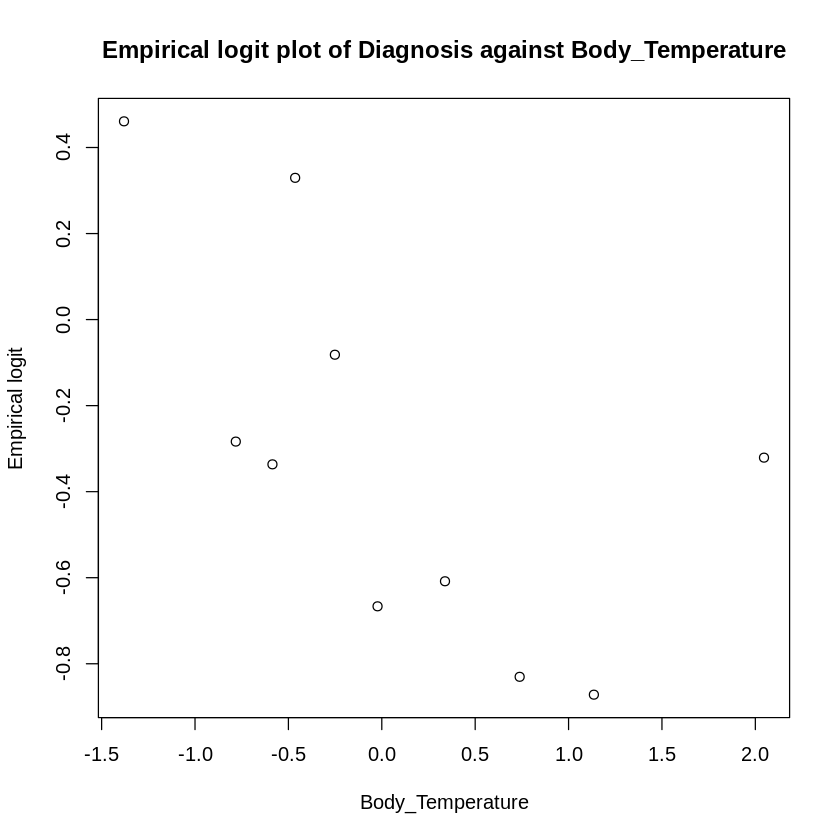

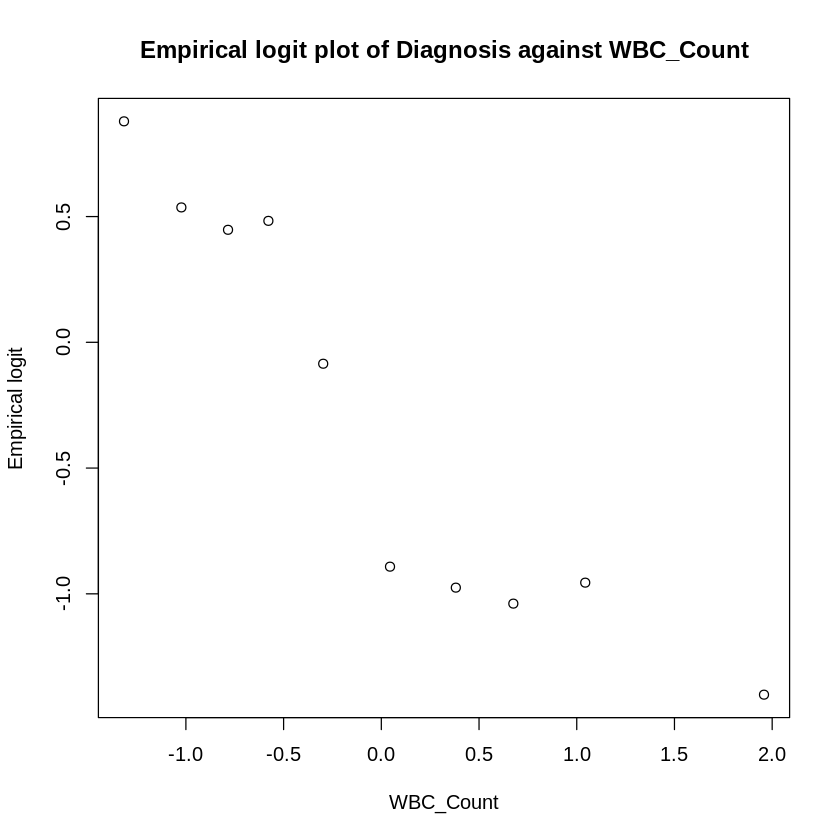

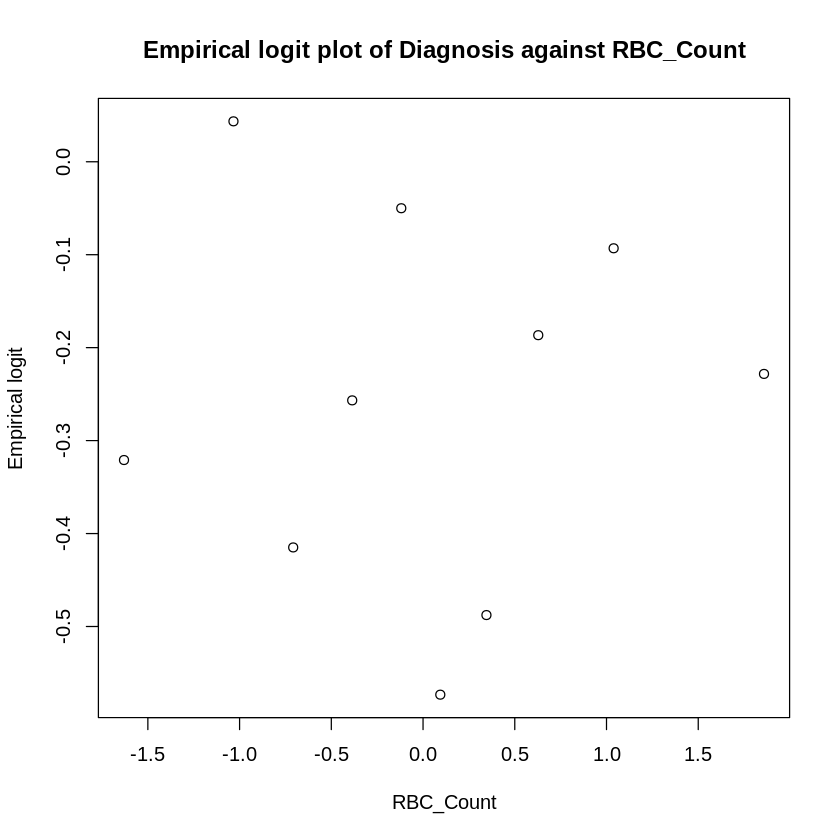

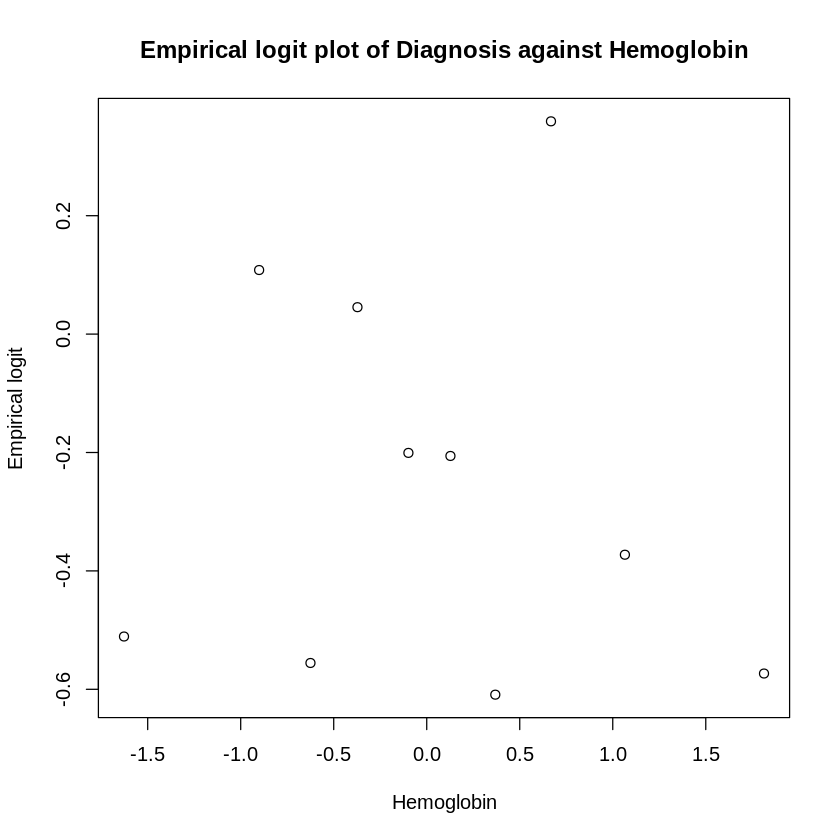

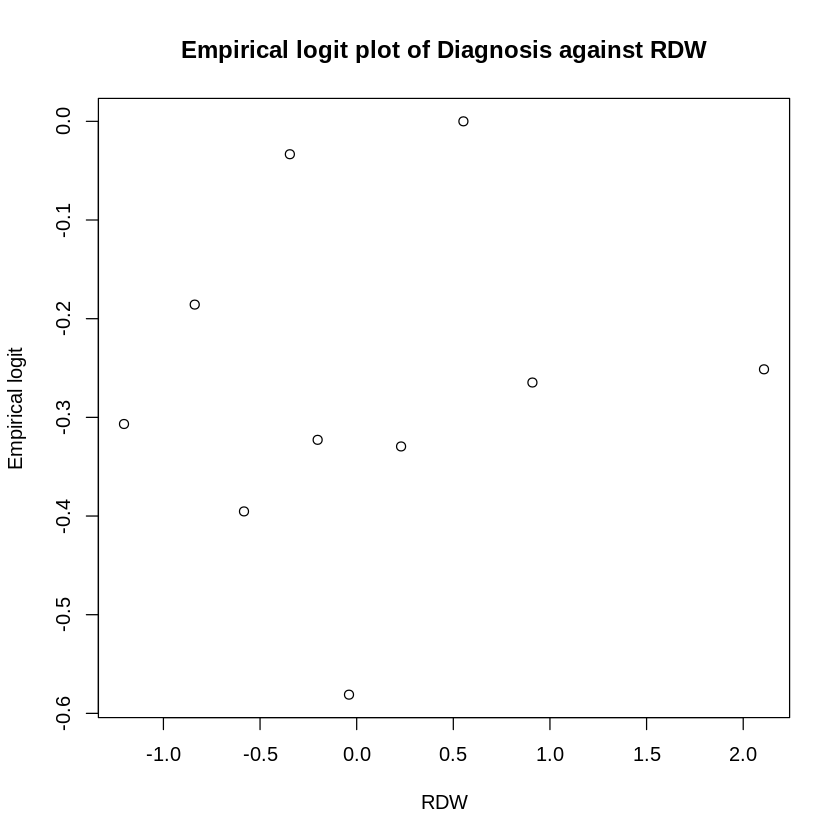

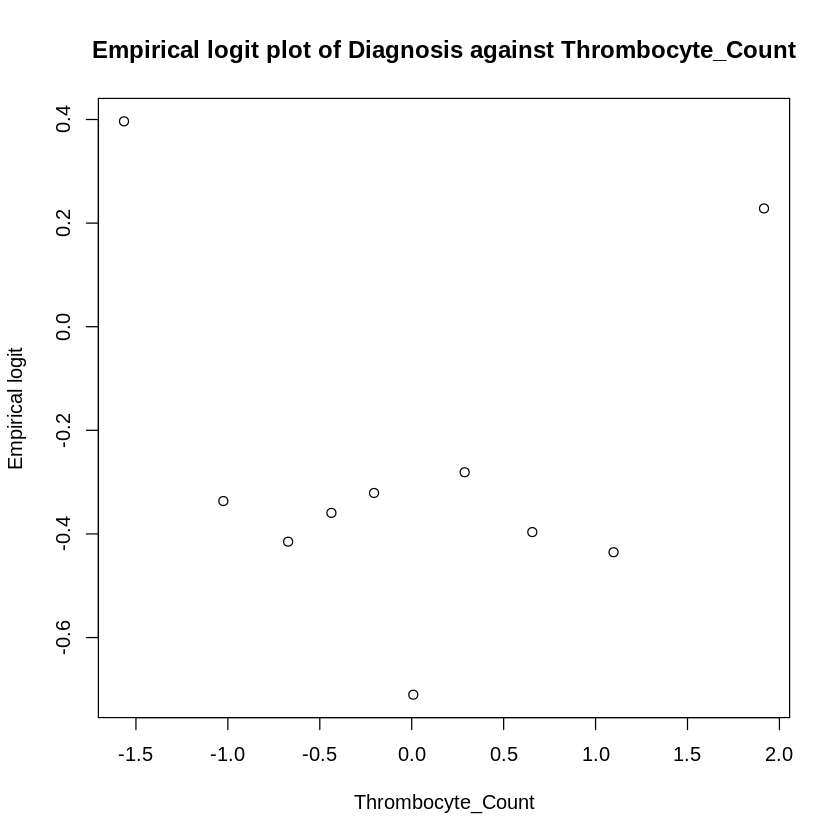

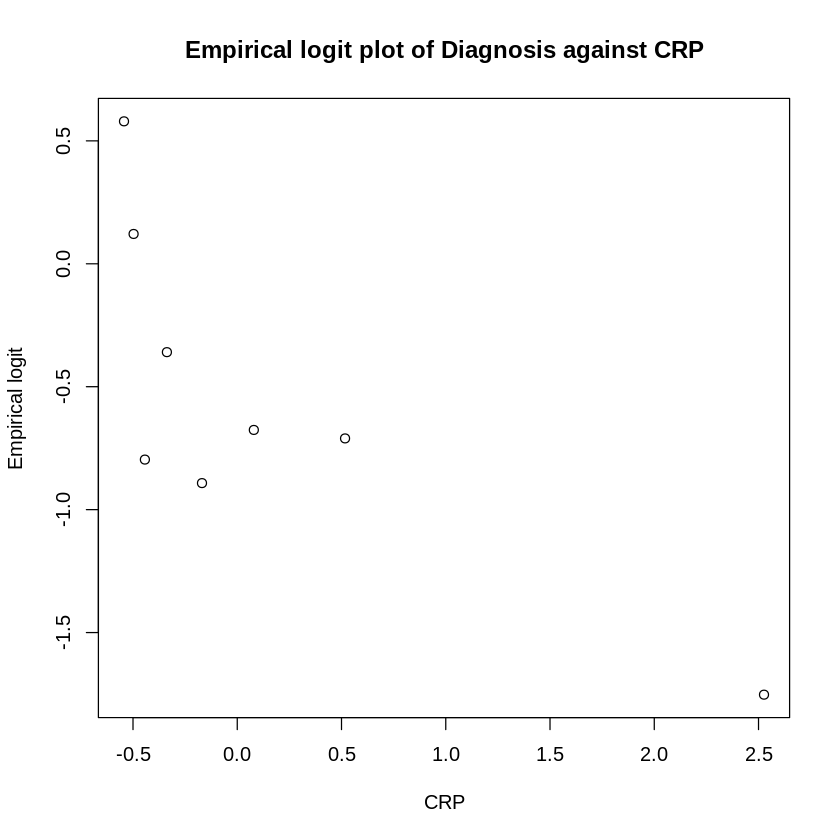

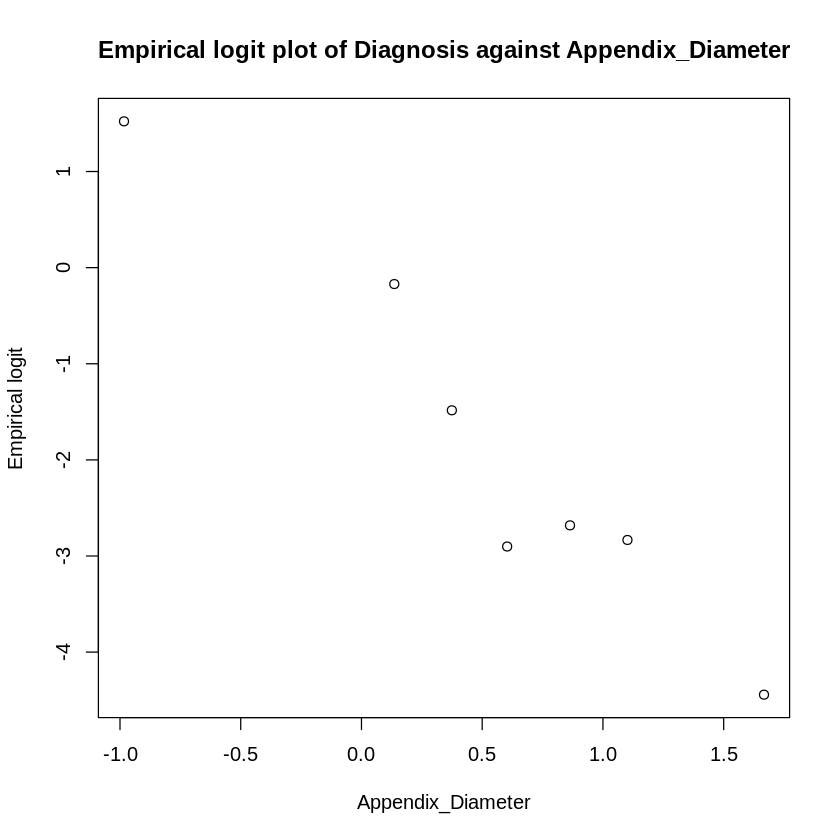

In [82]:
for (x in names(train_data[num])) {
  logitplot(train_data$Diagnosis,train_data[[x]],
  xlab=x, ylab='Empirical logit',
  main=sprintf('Empirical logit plot of Diagnosis against %s', x))
}
#They are mostly linear, I think

In [83]:
#Fitting the initial full model with all variables
full_model <- glm(Diagnosis01~.-Severity-Management-Diagnosis, data=train_data, family=binomial)
summary(full_model)


Call:
glm(formula = Diagnosis01 ~ . - Severity - Management - Diagnosis, 
    family = binomial, data = train_data)

Coefficients:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           8.614804   2.601398   3.312 0.000928 ***
Age                                   0.359017   0.441275   0.814 0.415880    
BMI                                   0.424119   0.980677   0.432 0.665396    
Sexmale                              -0.153906   0.439503  -0.350 0.726201    
Height                                0.323326   0.979697   0.330 0.741380    
Weight                               -0.911528   1.500722  -0.607 0.543590    
Alvarado_Score                        0.915302   0.730764   1.253 0.210378    
Paedriatic_Appendicitis_Score        -0.290365   1.016792  -0.286 0.775208    
Appendix_on_USyes                    -9.202148   1.751283  -5.255 1.48e-07 ***
Migratory_Painyes                     0.038370   0.630544   0.061 0.951477    

In [84]:
library(car)
car::vif(full_model)
#Collinearity reduce accuracy of the estimate of the regression coefficient
#Which reduces t-statistic and will cause it to become harder to reject Beta_i = 0 hypothesis
#To fix this issue, some redundant variables could be removed
#Variables like BMI and Alvarado_Score contain information from other variables
#I will try comparing model with raw clinical findings and score
#However, Appendix_on_US and Appendix_Diameter should still be prioritized

,GVIF,Df,GVIF^(1/(2*Df))
Age,5.806389,1,2.409645
BMI,23.522938,1,4.850045
Sex,1.522153,1,1.233756
Height,28.117512,1,5.302595
Weight,63.687044,1,7.980416
Alvarado_Score,15.608888,1,3.950809
Paedriatic_Appendicitis_Score,28.657248,1,5.353247
Appendix_on_US,23.062716,1,4.802366
Migratory_Pain,2.400310,1,1.549293
Lower_Right_Abd_Pain,2.130611,1,1.459661


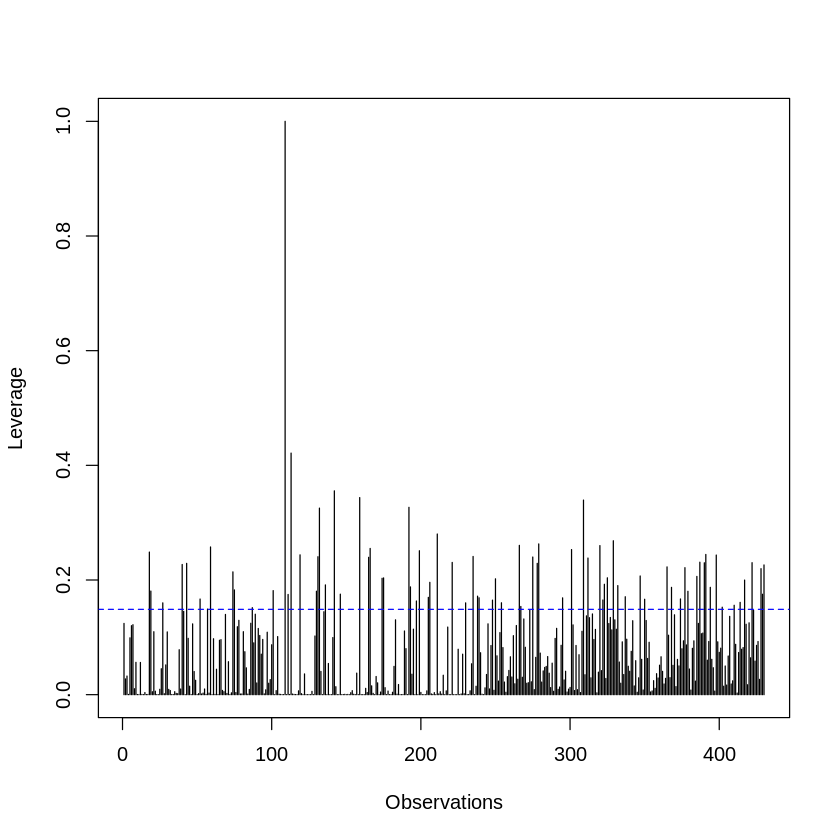

In [85]:
#Outlier detection
library(MASS)
h <- hatvalues(full_model)
cutoff <- 2*full_model$rank/nrow(train_data)
plot(h,ylab='Leverage', ylim=c(0,1),type="h", xlab='Observations')
abline(h=cutoff,col='blue',lty=2)

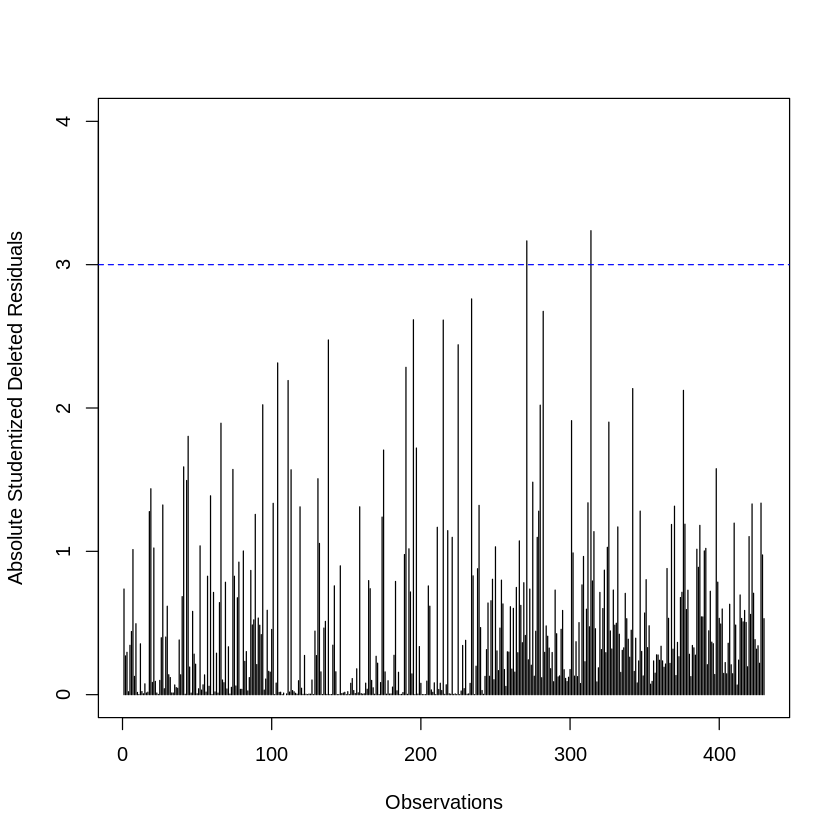

In [86]:
ext_stures <- rstudent(full_model)
plot(abs(ext_stures),ylab="Absolute Studentized Deleted Residuals",ylim=c(0,4),type="h", xlab='Observations')
cut_off <- 3
abline(h=cut_off,col="blue",lty=2)

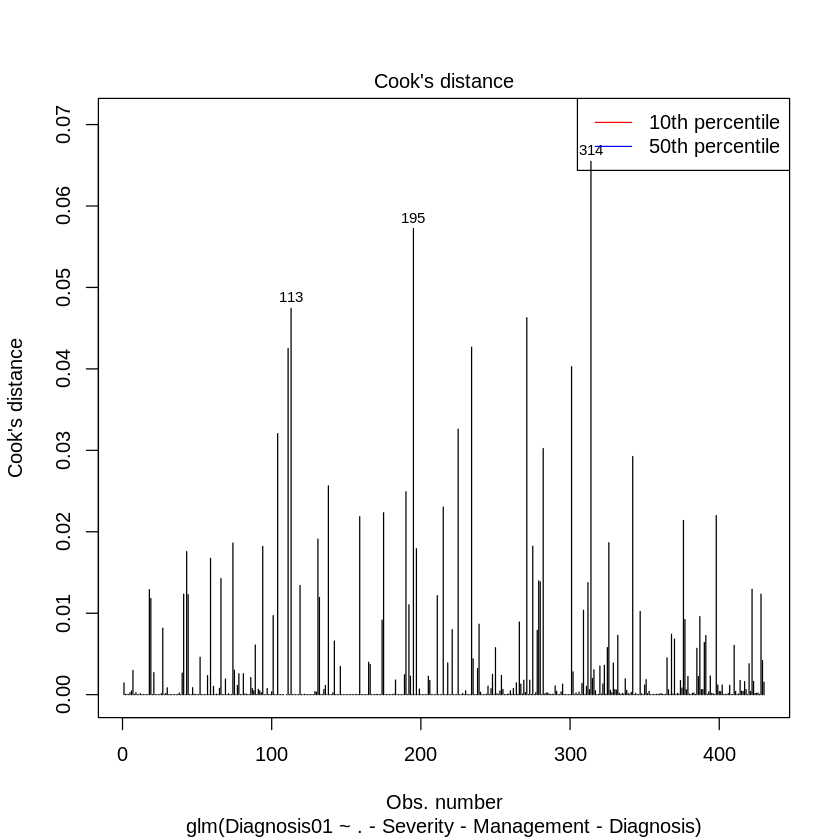

In [87]:
#Cook's distance
plot(full_model,4)
cutoff <- qf(0.2,3,full_model$df.residual)
abline(h=cutoff,col="red")
cutoff2 <- qf(0.5,3,full_model$df.residual)
abline(h=cutoff2,col="blue")
legend("topright", y=c("10th percentile","50th percentile"), lty=c(1,1), col=c("red","blue"))
#No influential points

In [88]:
#Exclude variables that contain the same information
#E.g. Alvarado score and BMI
#I think raw data should be preferred over simplified index like Alvarado score since it contain more information
trimmed_model <- glm(Diagnosis01~.-Severity-Management-Diagnosis
-Paedriatic_Appendicitis_Score-Alvarado_Score-BMI, data=train_data, family=binomial)
summary(trimmed_model)


Call:
glm(formula = Diagnosis01 ~ . - Severity - Management - Diagnosis - 
    Paedriatic_Appendicitis_Score - Alvarado_Score - BMI, family = binomial, 
    data = train_data)

Coefficients:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           7.431154   2.014032   3.690 0.000225 ***
Age                                   0.409755   0.418257   0.980 0.327248    
Sexmale                              -0.116659   0.432699  -0.270 0.787462    
Height                               -0.003903   0.520835  -0.007 0.994022    
Weight                               -0.281085   0.436023  -0.645 0.519150    
Appendix_on_USyes                    -9.040242   1.720269  -5.255 1.48e-07 ***
Migratory_Painyes                     0.256092   0.451132   0.568 0.570262    
Lower_Right_Abd_Painyes               1.249873   0.841985   1.484 0.137693    
Contralateral_Rebound_Tendernessyes   0.752503   0.414463   1.816 0.069430 .  
Coughing_Painyes  

In [89]:
vif(trimmed_model)
#Some multicollinearity remains, but it can't be helped
#I might switch to lasso if it has high impact on my model

,GVIF,Df,GVIF^(1/(2*Df))
Age,5.394099,1,2.322520
Sex,1.491506,1,1.221272
Height,8.273315,1,2.876337
Weight,5.512637,1,2.347901
Appendix_on_US,22.378625,1,4.730605
Migratory_Pain,1.243369,1,1.115065
Lower_Right_Abd_Pain,1.272754,1,1.128164
Contralateral_Rebound_Tenderness,1.313454,1,1.146060
Coughing_Pain,1.298254,1,1.139409
Nausea,1.462261,1,1.209240


In [90]:
#Stepwise selection with AIC
reduced_model <- step(trimmed_model, trace=F)
summary(reduced_model)


Call:
glm(formula = Diagnosis01 ~ Appendix_on_US + Lower_Right_Abd_Pain + 
    Contralateral_Rebound_Tenderness + Coughing_Pain + Nausea + 
    WBC_Count + CRP + Peritonitis + Free_Fluids + Appendix_Diameter, 
    family = binomial, data = train_data)

Coefficients:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           7.1110     1.7735   4.010 6.08e-05 ***
Appendix_on_USyes                    -8.4550     1.5504  -5.454 4.94e-08 ***
Lower_Right_Abd_Painyes               1.1731     0.7531   1.558 0.119307    
Contralateral_Rebound_Tendernessyes   0.6949     0.3855   1.803 0.071437 .  
Coughing_Painyes                      0.8060     0.4178   1.929 0.053675 .  
Nauseayes                             0.8512     0.3741   2.275 0.022886 *  
WBC_Count                             0.6833     0.2029   3.367 0.000760 ***
CRP                                   0.9863     0.2740   3.599 0.000319 ***
Peritonitislocal                     -0

In [91]:
#Goodness of fit
hosmerlem <-function (y, yhat, g = 10)
{
  cutyhat <- cut(yhat, breaks = quantile(yhat, probs = seq(0,1, 1/g)), include.lowest = T)
  obs <- xtabs(cbind(1 - y, y) ~ cutyhat)
  expect <- xtabs(cbind(1 - yhat, yhat) ~ cutyhat)
  chisq <- sum((obs - expect)^2/expect)
  P <- 1 - pchisq(chisq, g - 2)
  c("X^2" = chisq, Df = g - 2, "P(>Chi)" = P)
}
true_value <- as.numeric(levels(train_data$Diagnosis01))[train_data$Diagnosis01]
hosmerlem(true_value, reduced_model$fitted.values)
hosmerlem(true_value, trimmed_model$fitted.values)
#H0: model fits the data
#H1: model does not fit the data

X^2        Df   P(>Chi) 
6.0568561 8.0000000 0.6408631

X^2        Df   P(>Chi) 
5.1157548 8.0000000 0.7451355

In [92]:
#LRT test
anova(reduced_model,trimmed_model,test="LRT")
#H0: estimate of coefficient of variables only present in full model = 0
#H1: not H0

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,418,211.6571,NA,NA,NA
2,401,205.8383,17,5.818747,0.9943231


Setting levels: control = 0, case = 1

Setting direction: controls < cases



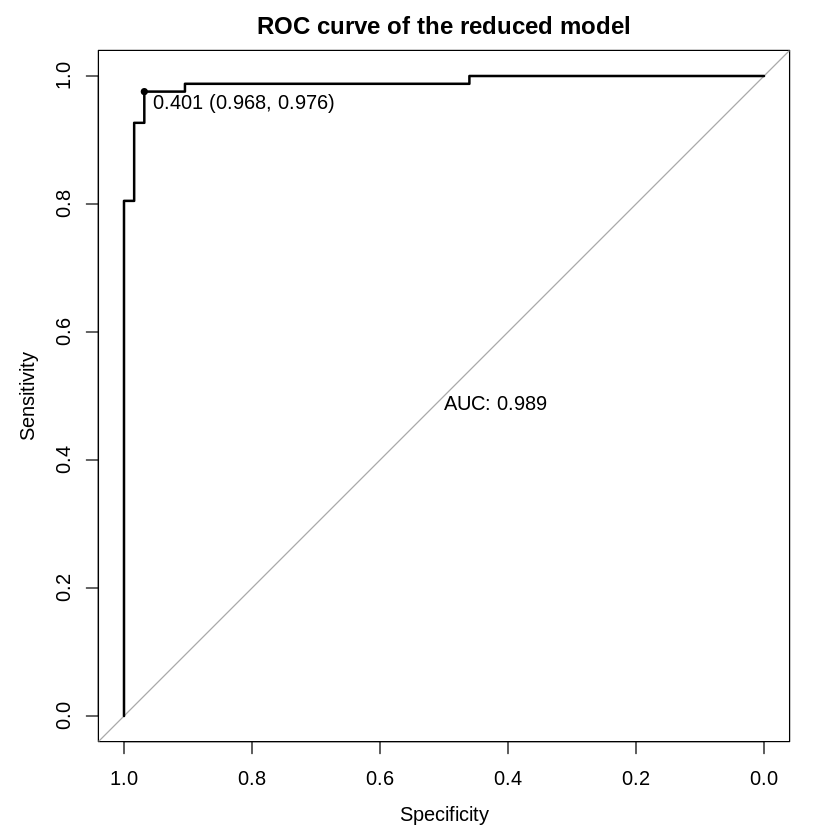

In [93]:
#ROC curve of the reduced model
library(pROC)
prob <- predict(reduced_model, newdata=test_data, type='response')
truth <- test_data$Diagnosis01
roc_curve <- roc(truth, prob, plot=TRUE, print.auc = TRUE, main="ROC curve of the reduced model", print.thres=TRUE)

In [94]:
optimal_cutoff <- coords(roc_curve, 'best', ret='threshold')
print(optimal_cutoff)

  threshold
1 0.4010362


In [95]:
draw_confusion_matrix <- function(cm, main_title) {

  layout(matrix(c(1,1,2)))
  par(mar=c(2,2,2,2))
  plot(c(100, 345), c(300, 450), type = "n", xlab="", ylab="", xaxt='n', yaxt='n')
  title(main_title, cex.main=2)

  # create the matrix
  rect(150, 430, 240, 370, col='#3F97D0')
  text(195, 435, 'No Appendicitis', cex=1.2)
  rect(250, 430, 340, 370, col='#F7AD50')
  text(295, 435, 'Appendicitis', cex=1.2)
  text(125, 370, 'Predicted', cex=1.3, srt=90, font=2)
  text(245, 450, 'Actual', cex=1.3, font=2)
  rect(150, 305, 240, 365, col='#F7AD50')
  rect(250, 305, 340, 365, col='#3F97D0')
  text(140, 400, 'No Appendicitis', cex=1.2, srt=90)
  text(140, 335, 'Appendicitis', cex=1.2, srt=90)

  # add in the cm results
  res <- as.numeric(cm$table)
  text(195, 400, res[1], cex=1.6, font=2, col='white')
  text(195, 335, res[2], cex=1.6, font=2, col='white')
  text(295, 400, res[3], cex=1.6, font=2, col='white')
  text(295, 335, res[4], cex=1.6, font=2, col='white')

  # add in the specifics
  plot(c(100, 0), c(100, 0), type = "n", xlab="", ylab="", main = "DETAILS", xaxt='n', yaxt='n')
  text(10, 85, names(cm$byClass[1]), cex=1.2, font=2)
  text(10, 70, round(as.numeric(cm$byClass[1]), 3), cex=1.2)
  text(30, 85, names(cm$byClass[2]), cex=1.2, font=2)
  text(30, 70, round(as.numeric(cm$byClass[2]), 3), cex=1.2)
  text(50, 85, names(cm$byClass[5]), cex=1.2, font=2)
  text(50, 70, round(as.numeric(cm$byClass[5]), 3), cex=1.2)
  text(70, 85, names(cm$byClass[6]), cex=1.2, font=2)
  text(70, 70, round(as.numeric(cm$byClass[6]), 3), cex=1.2)
  text(90, 85, names(cm$byClass[7]), cex=1.2, font=2)
  text(90, 70, round(as.numeric(cm$byClass[7]), 3), cex=1.2)

  # add in the accuracy information
  text(30, 35, names(cm$overall[1]), cex=1.5, font=2)
  text(30, 20, round(as.numeric(cm$overall[1]), 3), cex=1.4)
  text(70, 35, names(cm$overall[2]), cex=1.5, font=2)
  text(70, 20, round(as.numeric(cm$overall[2]), 3), cex=1.4)
}

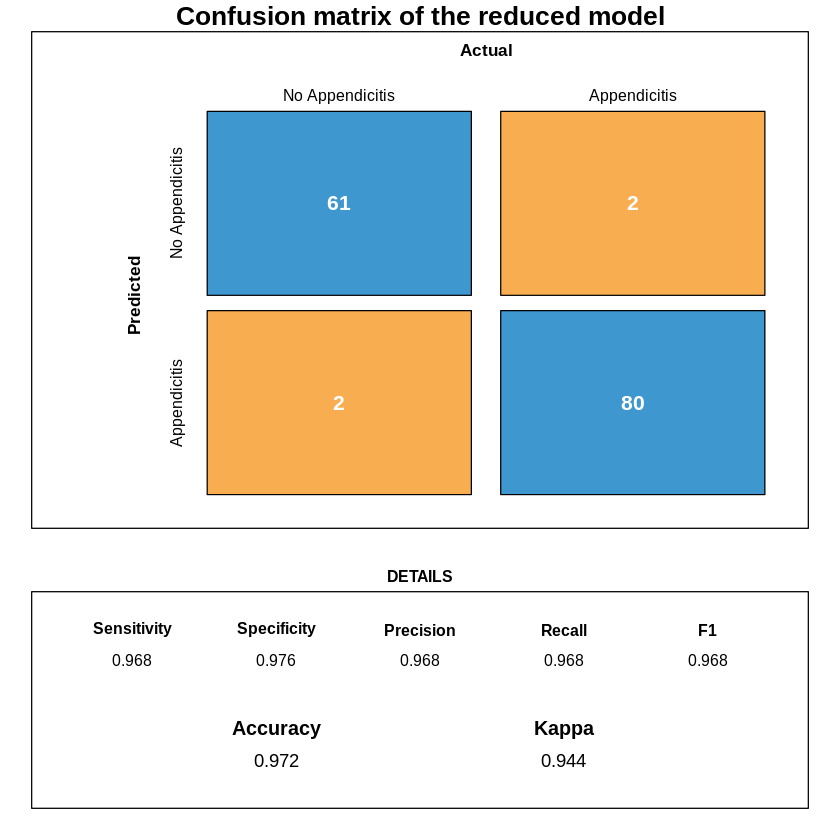

In [96]:
prob <- predict(reduced_model, newdata=test_data, type='response')
predclass <- rep(0, nrow(test_data))
predclass[prob>= optimal_cutoff[1,1]]<-1
predclass <- as.factor(predclass)
truth <- as.factor(test_data$Diagnosis01)

library(caret)
confuse <- confusionMatrix(reference=truth, data=predclass)
draw_confusion_matrix(confuse, "Confusion matrix of the reduced model")

Setting levels: control = 0, case = 1

Setting direction: controls < cases



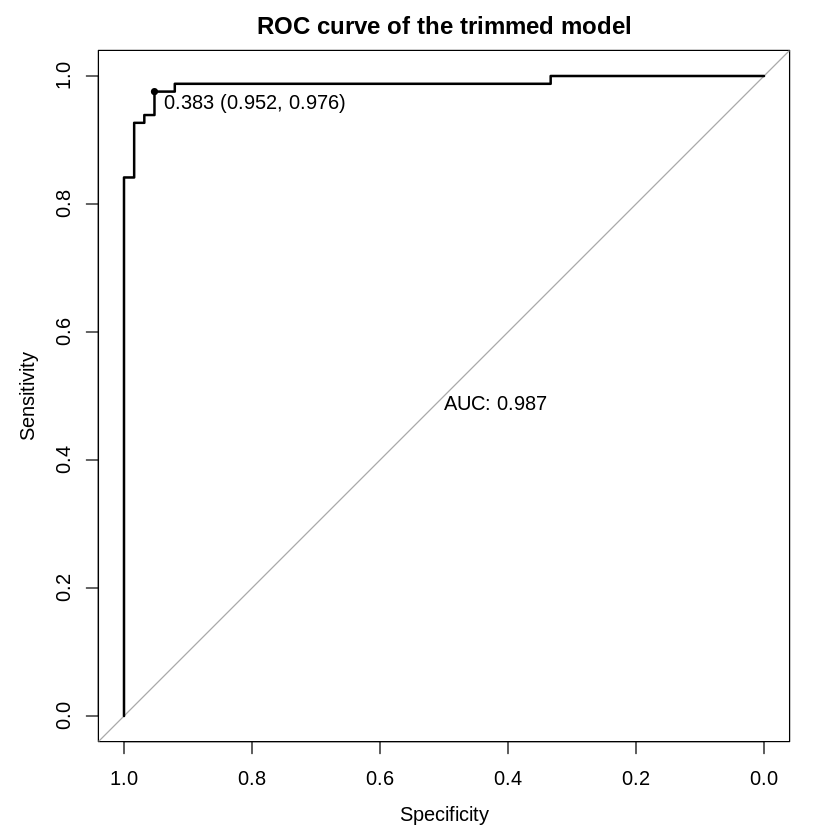

In [97]:
#Full model
prob <- predict(trimmed_model, newdata=test_data, type='response')
truth <- test_data$Diagnosis01
roc_curve <- roc(truth, prob, plot=TRUE, print.auc = TRUE, main="ROC curve of the trimmed model", print.thres=TRUE)
optimal_cutoff <- coords(roc_curve, 'best', ret='threshold')

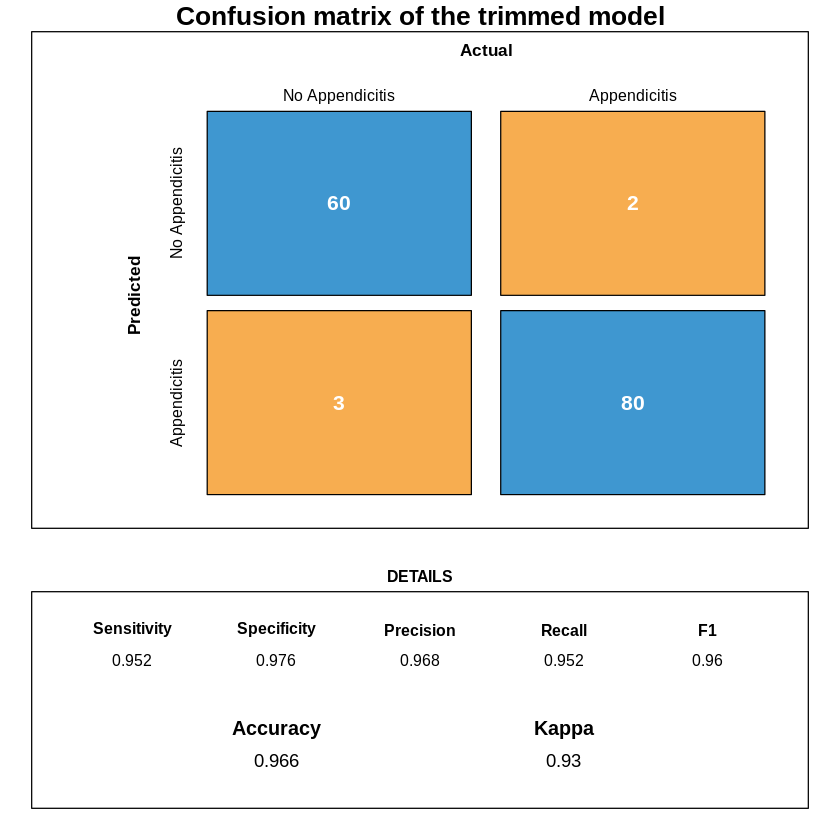

In [98]:
prob <- predict(trimmed_model, newdata=test_data, type='response')
predclass <- rep(0, nrow(test_data))
predclass[prob>= optimal_cutoff[1,1]]<-1
predclass <- as.factor(predclass)
truth <- as.factor(test_data$Diagnosis01)
confuse <- confusionMatrix(reference=truth, data=predclass)
draw_confusion_matrix(confuse, "Confusion matrix of the trimmed model")

In [99]:
#The reduced model perform better than the trimmed model because of overfitting

In [100]:
#Now to interpret the coefficients
summary(reduced_model)
#As expected, appendix diameter is the greatest predictor for appendicitis
#Important clinical variables are pain in lower right abdomen, contralateral rebound tenderness, couging pain and nausea
#Important lab variables are WBC count and CRP, which are indicators of inflammation
#This findings is in line with medical knowledge we already have


Call:
glm(formula = Diagnosis01 ~ Appendix_on_US + Lower_Right_Abd_Pain + 
    Contralateral_Rebound_Tenderness + Coughing_Pain + Nausea + 
    WBC_Count + CRP + Peritonitis + Free_Fluids + Appendix_Diameter, 
    family = binomial, data = train_data)

Coefficients:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           7.1110     1.7735   4.010 6.08e-05 ***
Appendix_on_USyes                    -8.4550     1.5504  -5.454 4.94e-08 ***
Lower_Right_Abd_Painyes               1.1731     0.7531   1.558 0.119307    
Contralateral_Rebound_Tendernessyes   0.6949     0.3855   1.803 0.071437 .  
Coughing_Painyes                      0.8060     0.4178   1.929 0.053675 .  
Nauseayes                             0.8512     0.3741   2.275 0.022886 *  
WBC_Count                             0.6833     0.2029   3.367 0.000760 ***
CRP                                   0.9863     0.2740   3.599 0.000319 ***
Peritonitislocal                     -0

In [101]:
#Extra

In [102]:
#Explanatory variables are seperated into categories like clinical, laboratory, ultrasound and score
#Data in certain category like ultrasound are also obtained later than clinical
#Score like Alvarado are also derived from clinical and lab findings
#I want to try what will happen if we only include variables from clinical and lab category

In [103]:
#Model_1 only contain clinical findings
#Give very bad prediction (around 60% accuracy)
model_1 <- glm(Diagnosis01~Migratory_Pain+Lower_Right_Abd_Pain
+Contralateral_Rebound_Tenderness+Coughing_Pain+Psoas_Sign+Nausea+Loss_of_Appetite
+Body_Temperature+Dysuria+Stool, data=train_data, family=binomial)

#Model2: Lab value + clinical findings
model_2 <- glm(Diagnosis01~Migratory_Pain+Lower_Right_Abd_Pain
+Contralateral_Rebound_Tenderness+Coughing_Pain+Psoas_Sign+Nausea+Loss_of_Appetite
+Body_Temperature+Dysuria+Stool+WBC_Count+RBC_Count+Hemoglobin+RDW+Thrombocyte_Count
+Neutrophilia+CRP, data=train_data, family=binomial)

In [104]:
step2 <- step(model_2, trace=F)
summary(step2)


Call:
glm(formula = Diagnosis01 ~ Lower_Right_Abd_Pain + Contralateral_Rebound_Tenderness + 
    Psoas_Sign + Nausea + Body_Temperature + WBC_Count + Neutrophilia + 
    CRP, family = binomial, data = train_data)

Coefficients:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                          -1.5777     0.5564  -2.835 0.004576 ** 
Lower_Right_Abd_Painyes               1.5121     0.5322   2.841 0.004493 ** 
Contralateral_Rebound_Tendernessyes   0.5090     0.2383   2.136 0.032652 *  
Psoas_Signyes                        -0.5486     0.2473  -2.219 0.026521 *  
Nauseayes                             0.5736     0.2246   2.554 0.010657 *  
Body_Temperature                     -0.2120     0.1295  -1.638 0.101507    
WBC_Count                             0.4634     0.1602   2.893 0.003815 ** 
Neutrophiliayes                       0.5127     0.2922   1.755 0.079308 .  
CRP                                   0.7417     0.2118   3.502 0.000461 ***
-

Setting levels: control = 0, case = 1

Setting direction: controls < cases



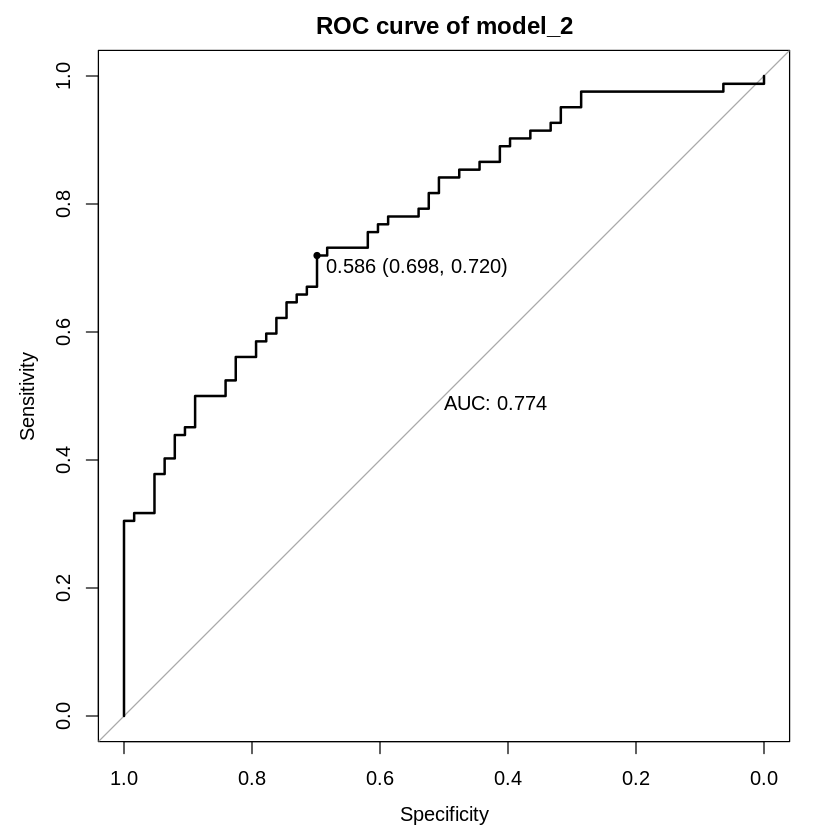

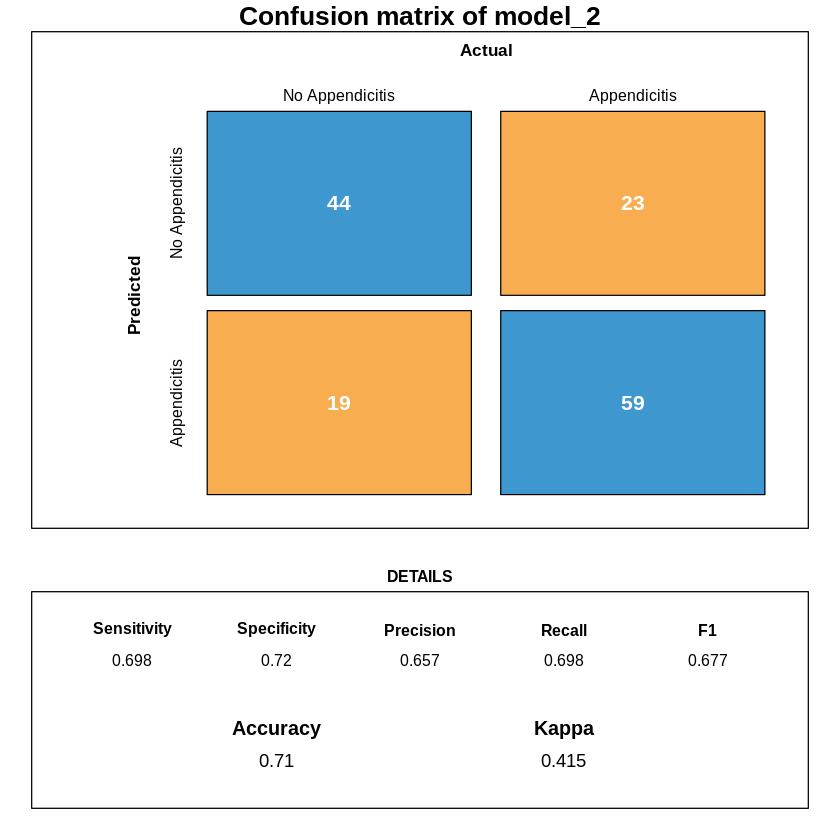

In [105]:
#Model 2
prob <- predict(model_2, newdata=test_data, type='response')
truth <- test_data$Diagnosis01
roc_curve <- roc(truth, prob, plot=TRUE, print.auc = TRUE, main="ROC curve of model_2", print.thres=TRUE)
optimal_cutoff <- coords(roc_curve, 'best', ret='threshold')

prob <- predict(model_2, newdata=test_data, type='response')
predclass <- rep(0, nrow(test_data))
predclass[prob>= optimal_cutoff[1,1]]<-1
predclass <- as.factor(predclass)
truth <- as.factor(test_data$Diagnosis01)

library(caret)
confuse <- confusionMatrix(reference=truth, data=predclass)
draw_confusion_matrix(confuse, "Confusion matrix of model_2")

Setting levels: control = 0, case = 1

Setting direction: controls < cases



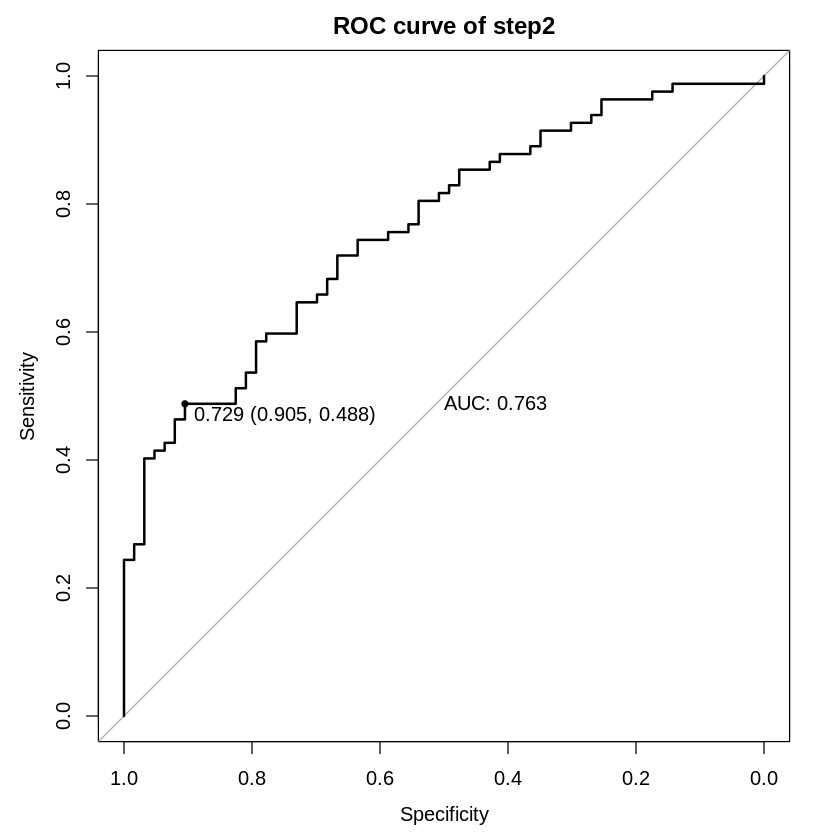

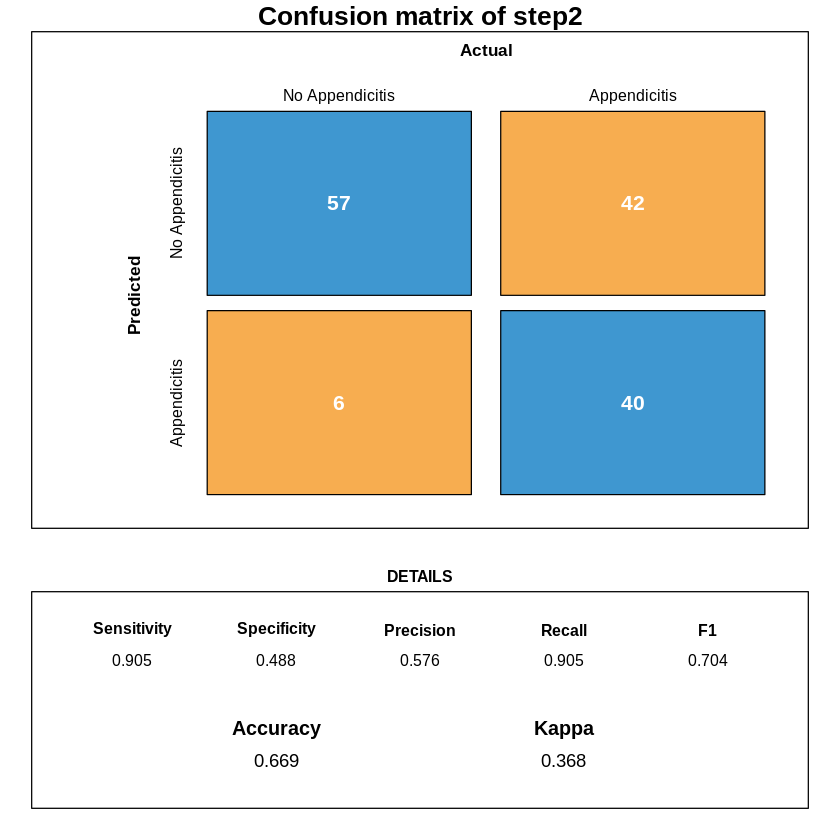

In [106]:
prob <- predict(step2, newdata=test_data, type='response')
truth <- test_data$Diagnosis01
roc_curve <- roc(truth, prob, plot=TRUE, print.auc = TRUE, main="ROC curve of step2", print.thres=TRUE)
optimal_cutoff <- coords(roc_curve, 'best', ret='threshold')
prob <- predict(step2, newdata=test_data, type='response')
predclass <- rep(0, nrow(test_data))
predclass[prob>= optimal_cutoff[1,1]]<-1
predclass <- as.factor(predclass)
truth <- as.factor(test_data$Diagnosis01)

library(caret)
confuse <- confusionMatrix(reference=truth, data=predclass)
draw_confusion_matrix(confuse, "Confusion matrix of step2")
#Without ultrasound data, the model isn't very reliable
#This just show how important an ultrasound is to diagnosis